<a href="https://www.kaggle.com/code/omborse771924/ai-data-science-job-salaries-eda-94-acc?scriptVersionId=339544833" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv')

In [3]:
df.head()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


In [4]:
df.tail()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
4995,Data Analyst,Mid,Full-time,M,PL,PL,Finance,50,9.3,Masters,...,1.5,PLN,38810,0.182,12.0,7.3,2,False,7.8,4.8
4996,Machine Learning Engineer,Lead,Full-time,M,ES,ES,Technology,0,13.3,Self-taught,...,2.6,EUR,123368,0.000,11.0,5.5,7,False,4.0,1.3
4997,Data Science Manager,Senior,Full-time,M,PL,PL,Technology,50,8.1,Bachelors,...,9.7,PLN,86123,0.078,13.3,7.0,6,True,19.2,2.7
4998,Research Scientist,Senior,Freelance,M,PL,PL,Technology,0,12.9,Bachelors,...,10.7,PLN,76001,0.122,10.1,6.0,4,True,10.8,1.5
4999,Business Intelligence Analyst,Entry,Contract,M,US,US,Government,0,2.1,Masters,...,10.4,USD,49321,0.022,4.8,6.6,3,False,6.9,6.1


In [5]:
df.info

<bound method DataFrame.info of                           job_title experience_level employment_type  \
0                      Data Analyst             Lead       Part-time   
1                Research Scientist           Senior       Full-time   
2         Machine Learning Engineer            Entry       Full-time   
3                     Data Engineer           Senior       Full-time   
4                     Data Engineer              Mid       Full-time   
...                             ...              ...             ...   
4995                   Data Analyst              Mid       Full-time   
4996      Machine Learning Engineer             Lead       Full-time   
4997           Data Science Manager           Senior       Full-time   
4998             Research Scientist           Senior       Freelance   
4999  Business Intelligence Analyst            Entry        Contract   

     company_size company_location employee_residence    industry  \
0               S               IN

In [6]:
df.describe()

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.361440,7.93620,1.820400,44.345400,8.437400,98605.406200,0.139020,10.802720,6.685320,5.230800,8.680740,4.846080
std,41.45428,4.820808,2.64793,1.344212,6.142761,5.503637,55369.310473,0.184243,5.152959,1.364302,2.412695,4.422549,1.725924
min,0.00000,0.000000,1.00000,0.000000,24.400000,0.000000,12000.000000,0.000000,0.000000,1.100000,1.000000,0.000000,1.000000
25%,0.00000,4.800000,6.00000,1.000000,40.100000,3.300000,55592.750000,0.017000,7.100000,5.800000,3.000000,5.600000,3.700000
50%,50.00000,8.100000,8.00000,2.000000,44.400000,8.500000,90572.000000,0.072000,10.600000,6.700000,5.000000,8.700000,4.800000
75%,100.00000,11.500000,10.00000,3.000000,48.500000,12.625000,129657.750000,0.175000,14.200000,7.600000,7.000000,11.700000,6.000000
max,100.00000,23.700000,19.00000,8.000000,67.300000,25.200000,372347.000000,1.264000,30.800000,10.000000,16.000000,26.200000,10.000000


In [7]:
df.isnull

<bound method DataFrame.isnull of                           job_title experience_level employment_type  \
0                      Data Analyst             Lead       Part-time   
1                Research Scientist           Senior       Full-time   
2         Machine Learning Engineer            Entry       Full-time   
3                     Data Engineer           Senior       Full-time   
4                     Data Engineer              Mid       Full-time   
...                             ...              ...             ...   
4995                   Data Analyst              Mid       Full-time   
4996      Machine Learning Engineer             Lead       Full-time   
4997           Data Science Manager           Senior       Full-time   
4998             Research Scientist           Senior       Freelance   
4999  Business Intelligence Analyst            Entry        Contract   

     company_size company_location employee_residence    industry  \
0               S               

In [8]:
df.isnull().sum()

job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry', 'remote_ratio',
       'years_experience', 'education_level', 'primary_language',
       'has_ml_in_title', 'manages_people', 'team_size',
       'certifications_count', 'weekly_hours', 'uses_ai_tools_daily',
       'ai_tools_hours_per_week', 'salary_currency', 'salary_usd',
       'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score',
       'interviews_to_offer', 'switched_jobs_last_year',
       'upskilling_hours_per_month', 'fears_ai_automation_score'],
      dtype='object')

## EDA

DATASET SHAPE
(5000, 27)
DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   object 
 1   experience_level            5000 non-null   object 
 2   employment_type             5000 non-null   object 
 3   company_size                5000 non-null   object 
 4   company_location            5000 non-null   object 
 5   employee_residence          5000 non-null   object 
 6   industry                    5000 non-null   object 
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   object 
 10  primary_language            5000 non-null   object 
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   


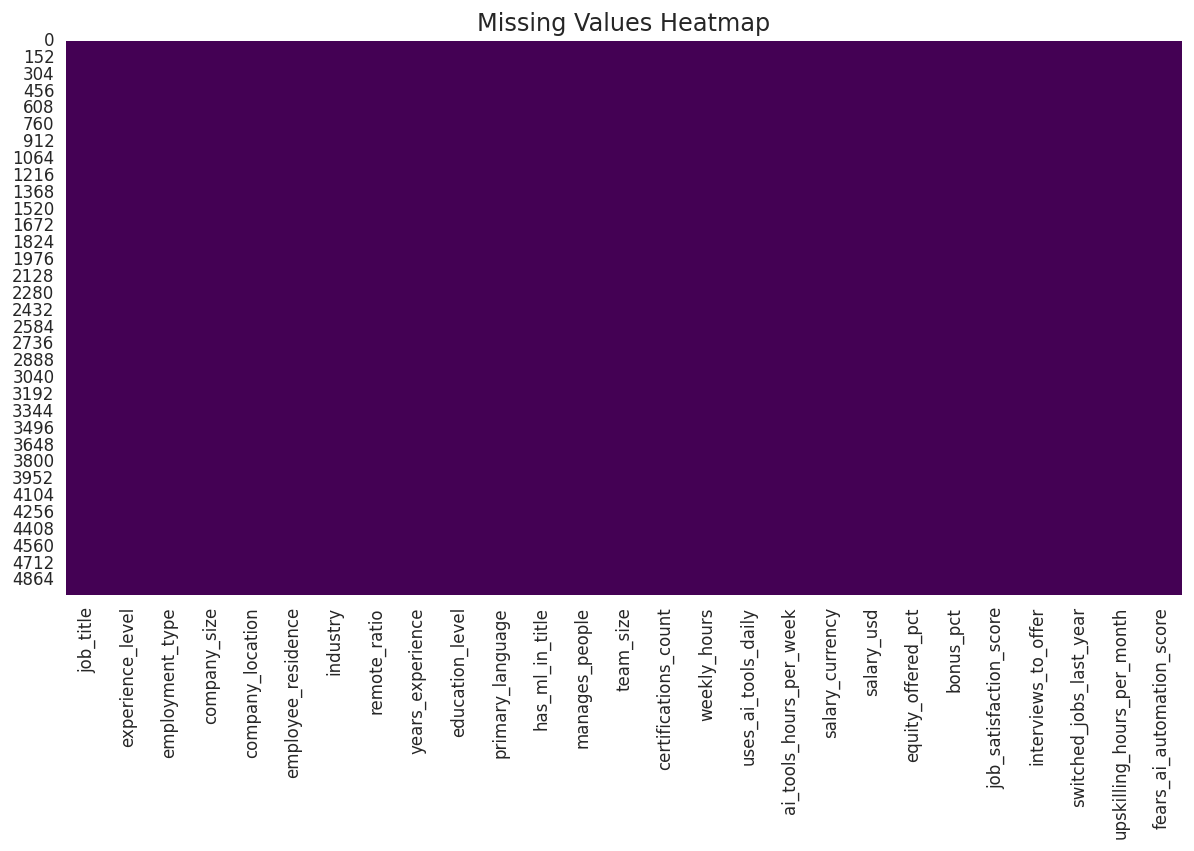

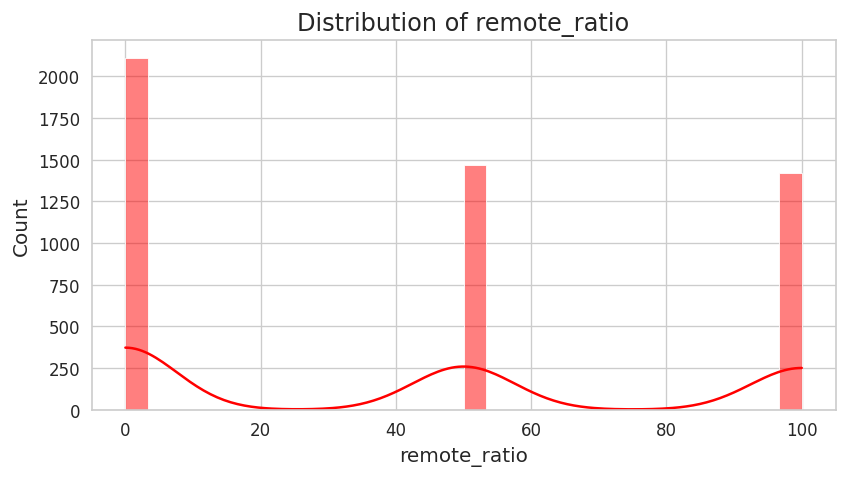

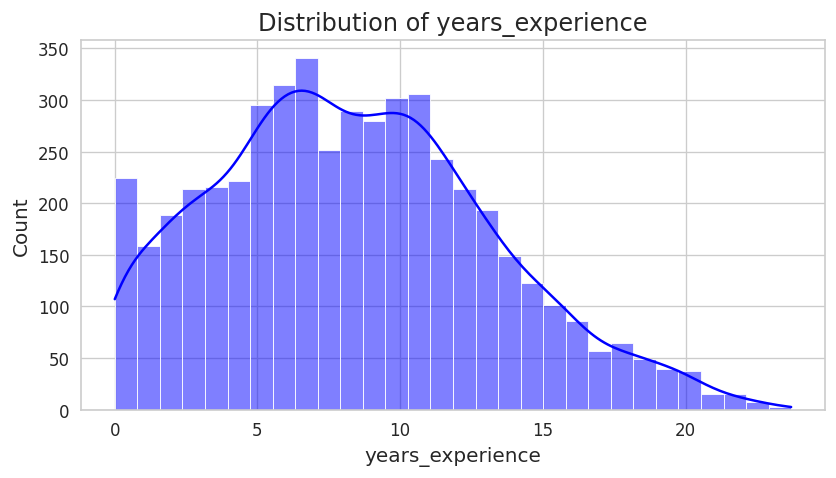

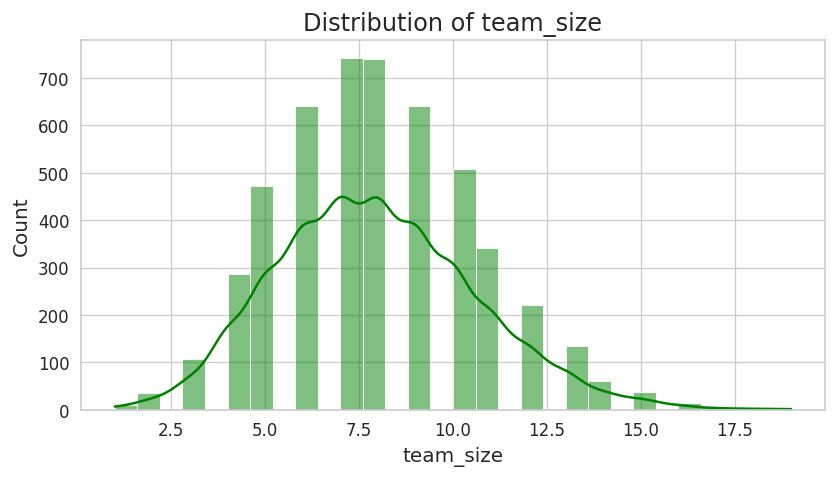

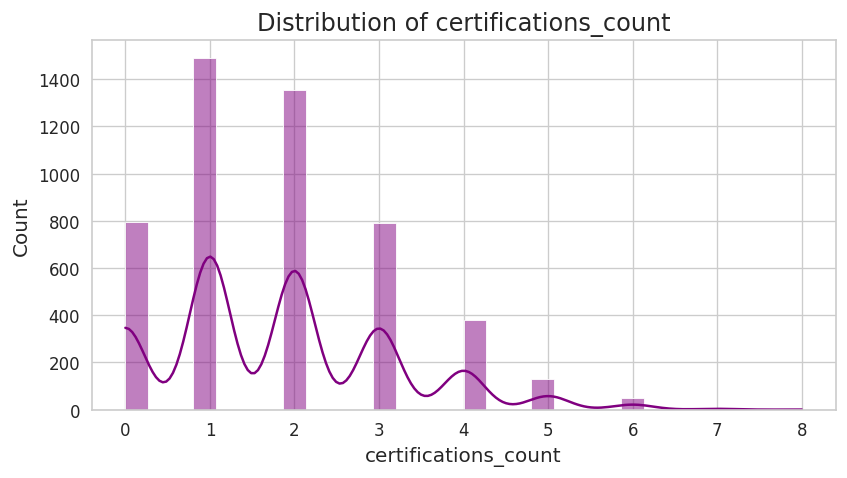

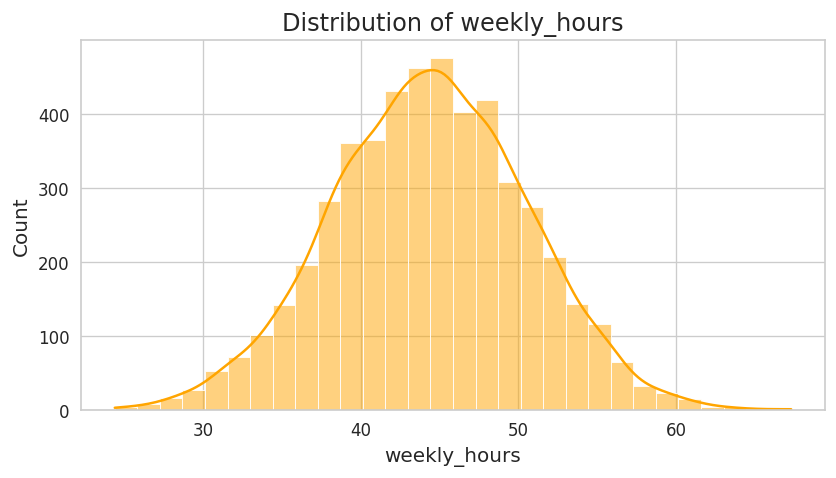

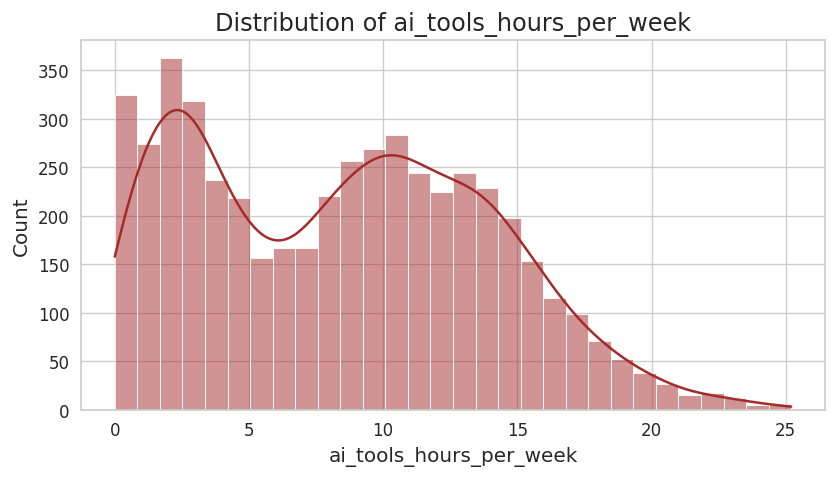

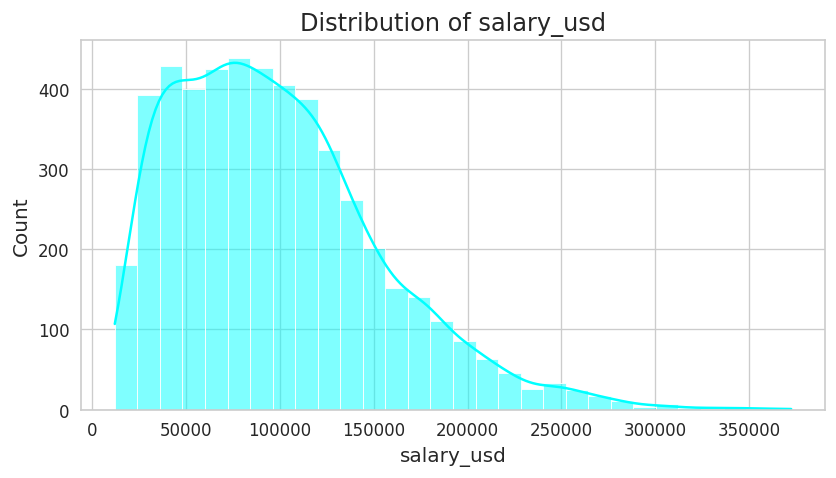

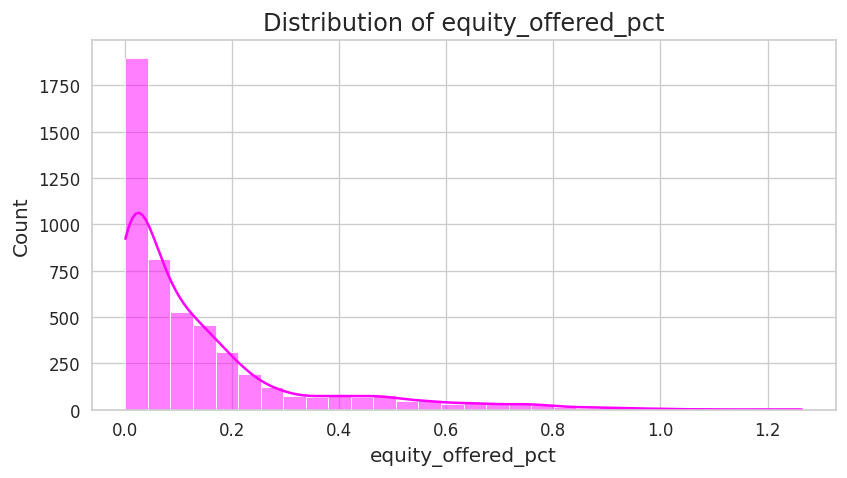

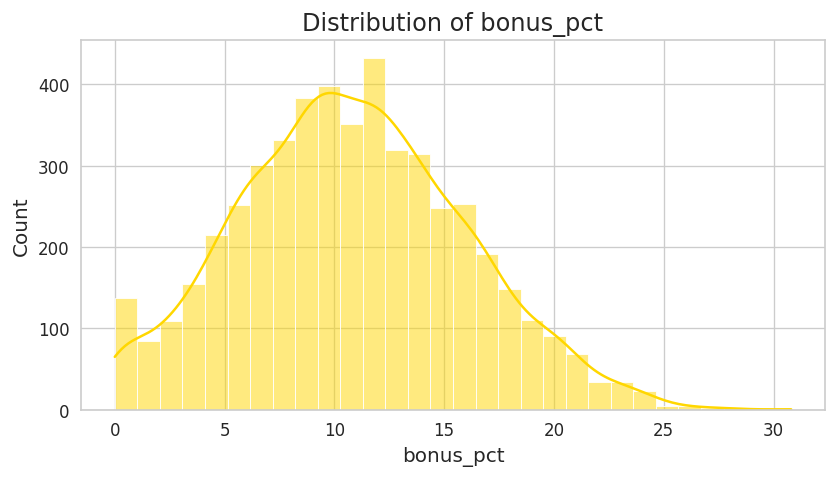

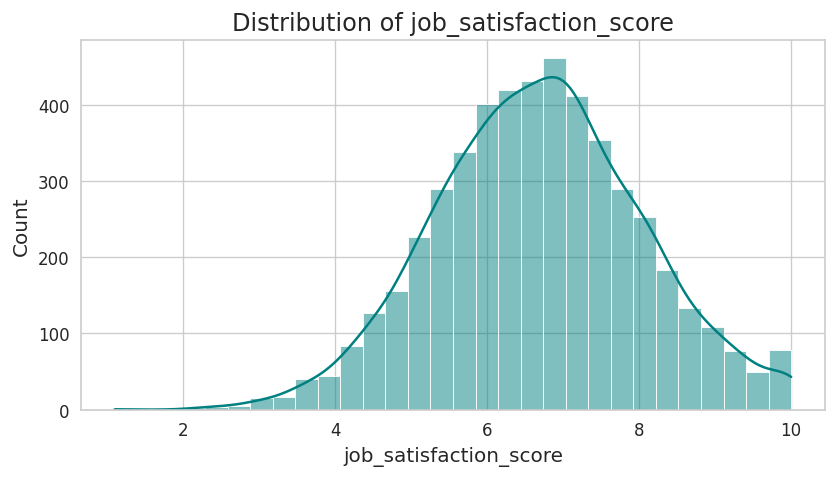

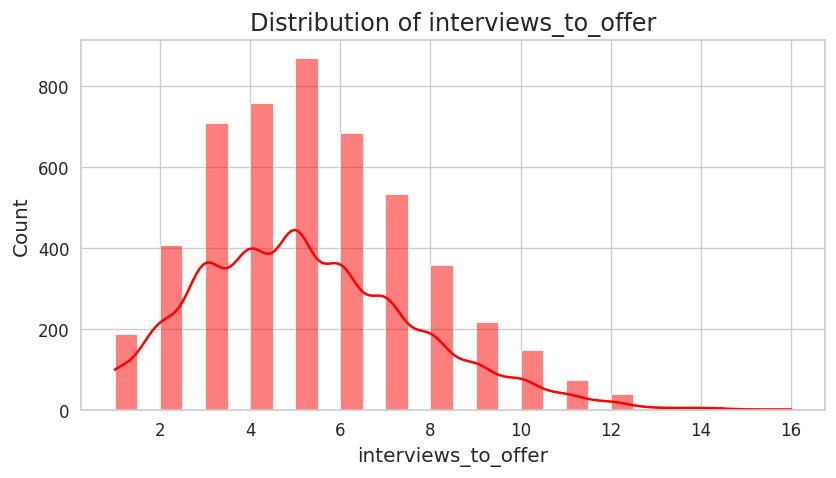

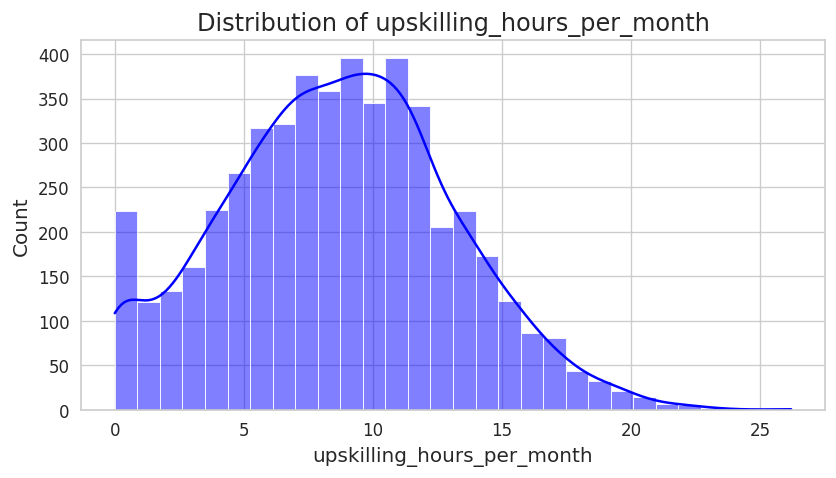

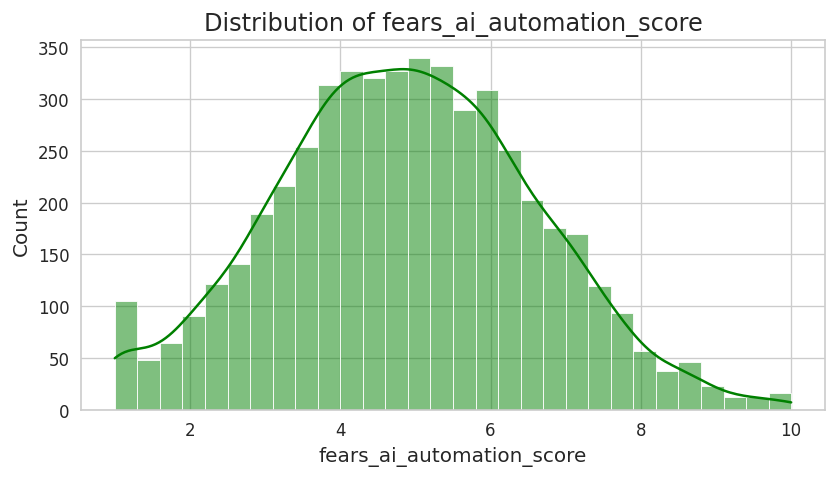

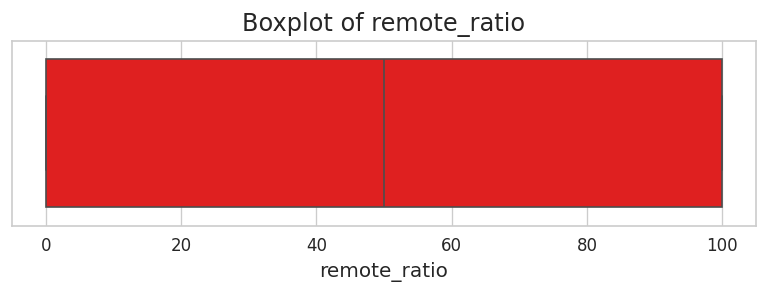

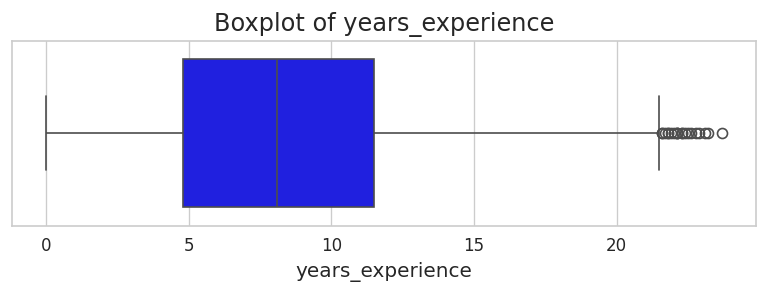

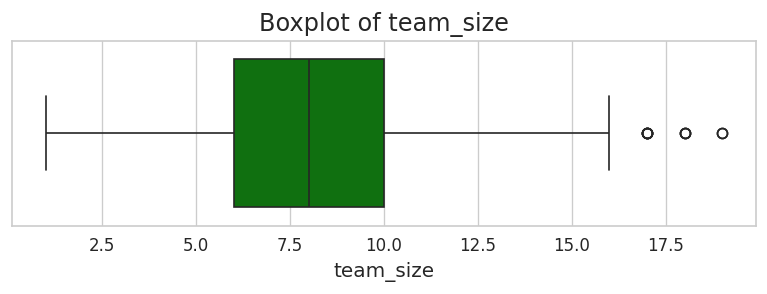

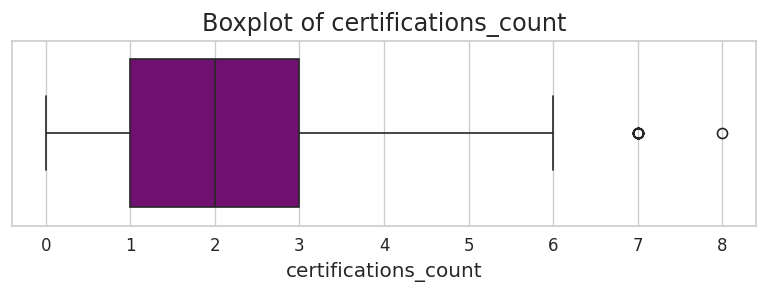

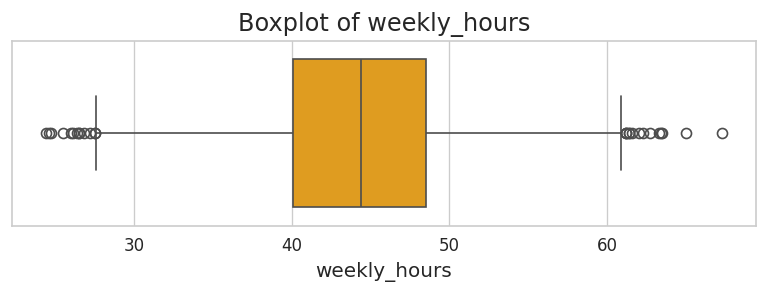

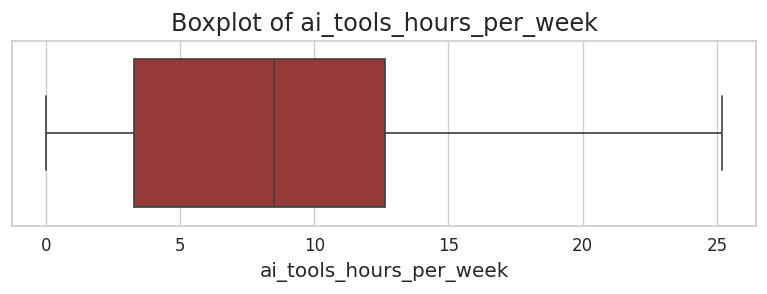

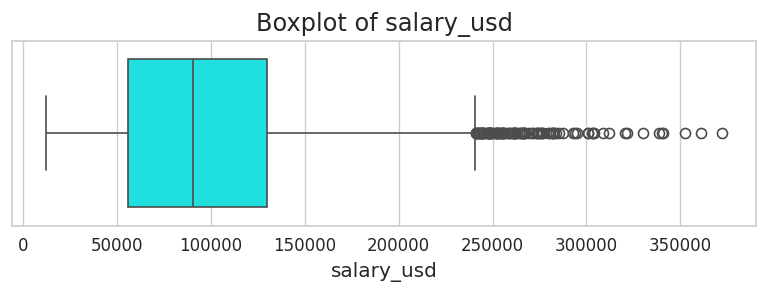

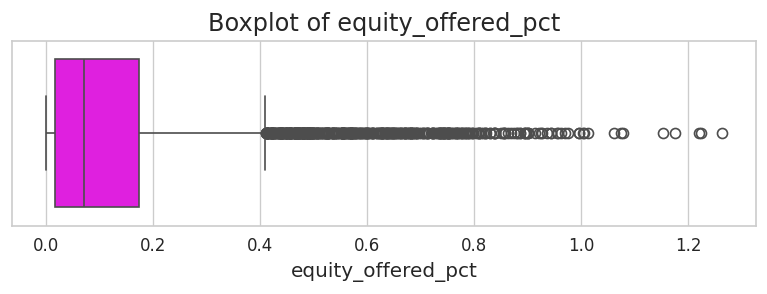

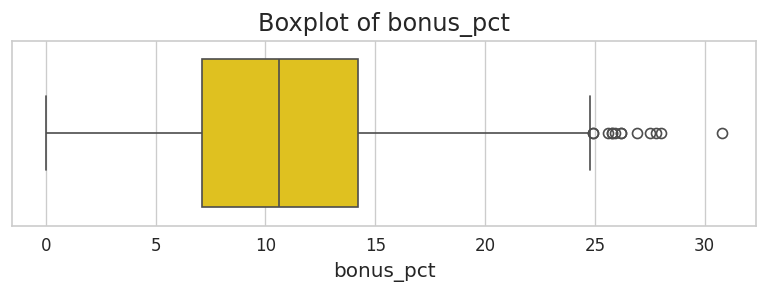

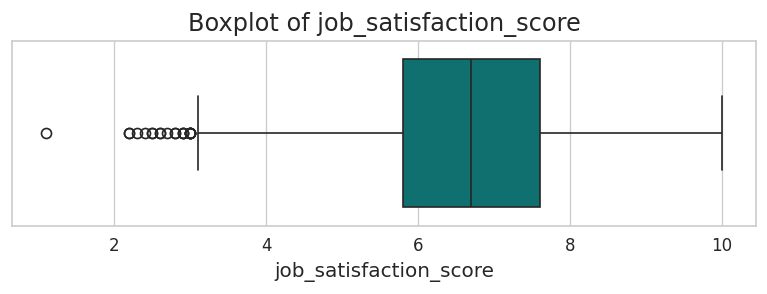

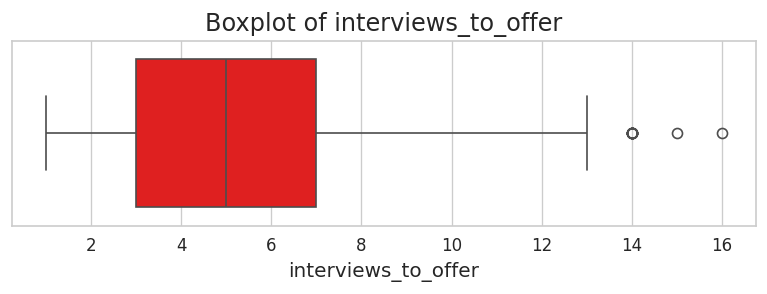

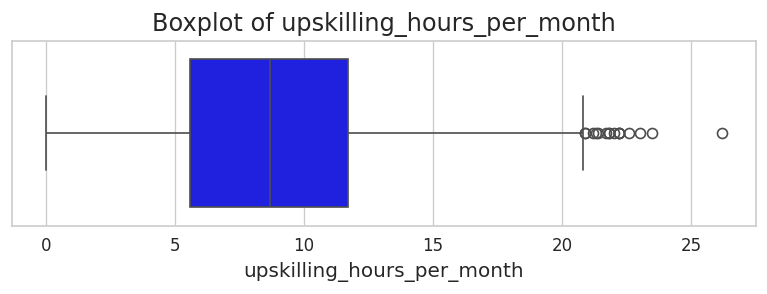

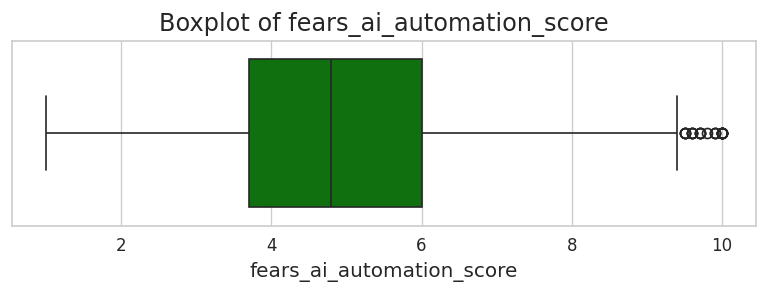

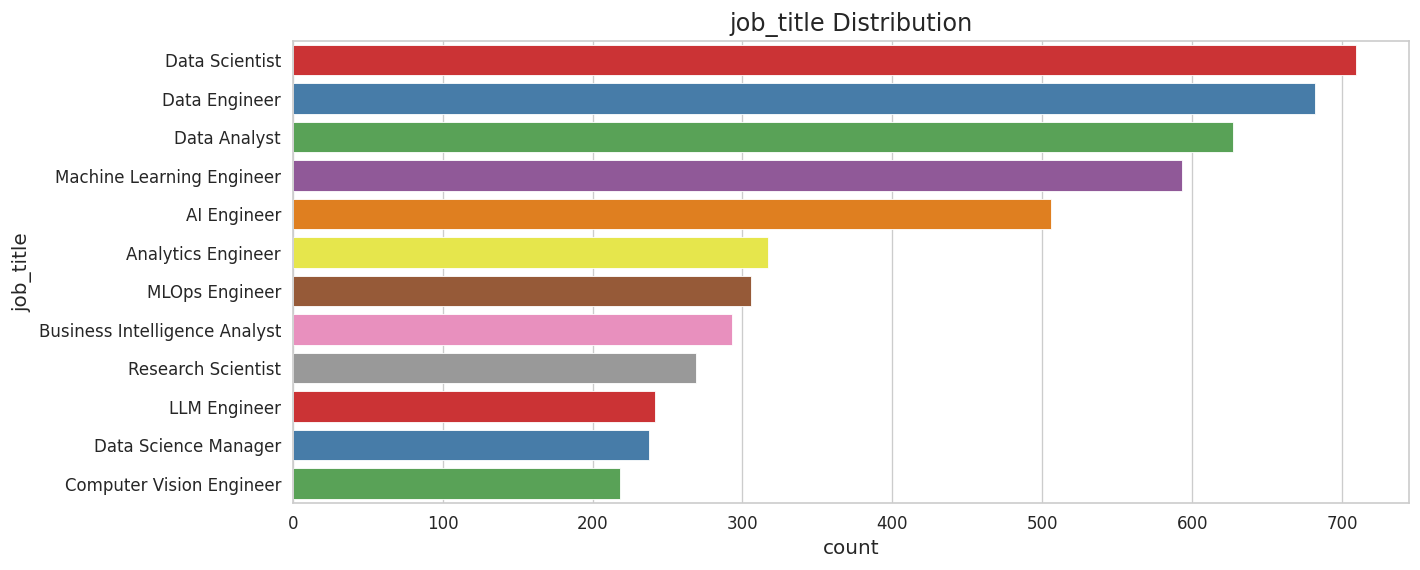

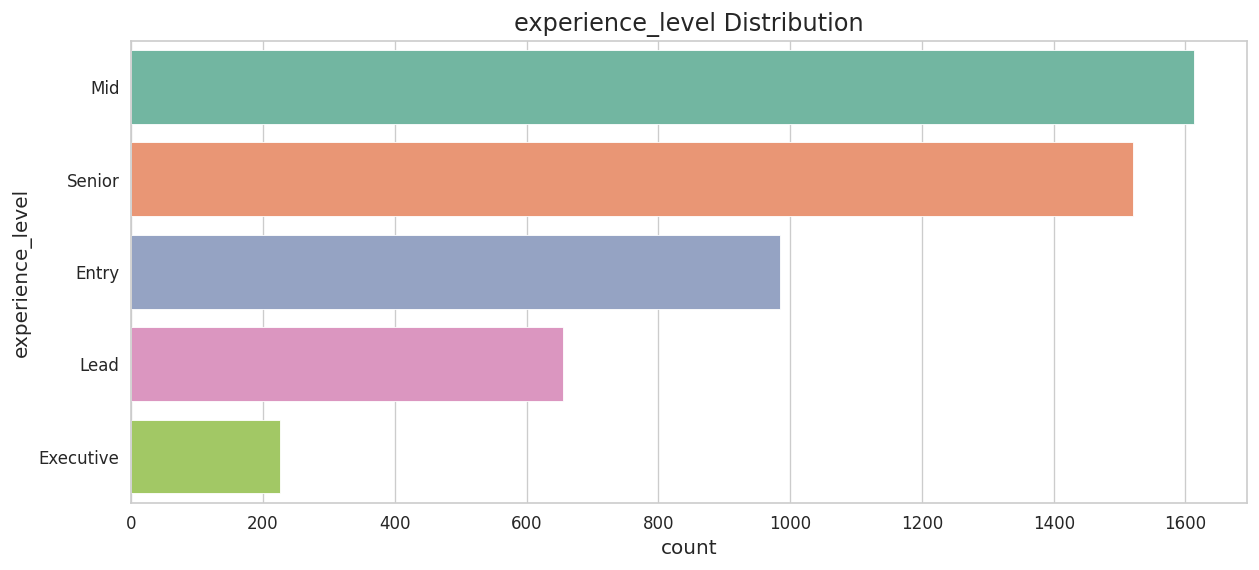

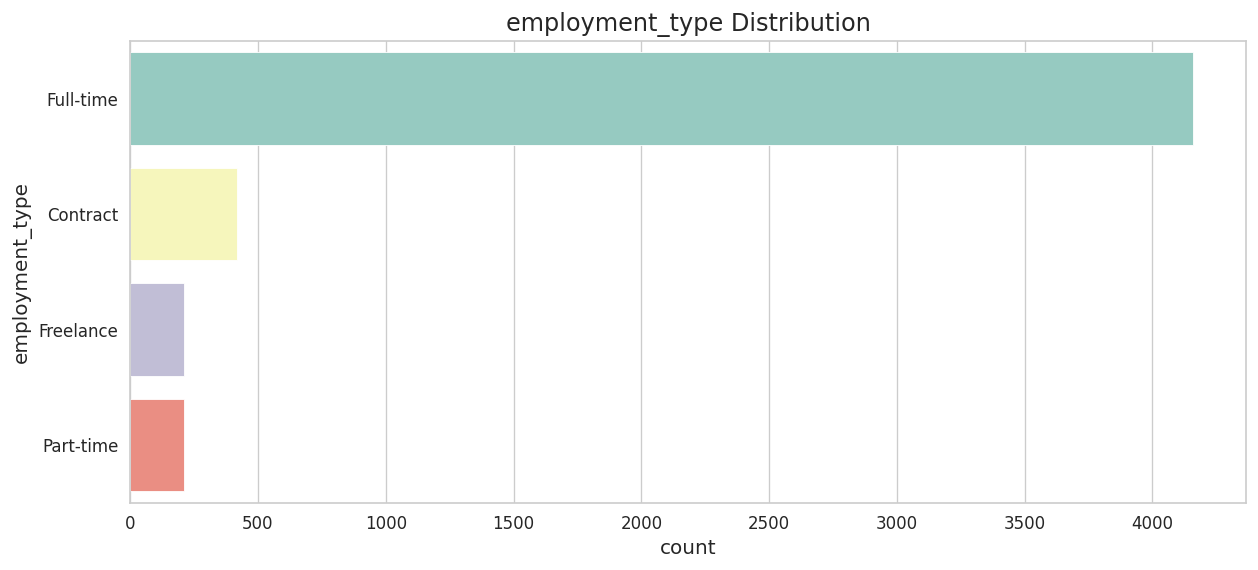

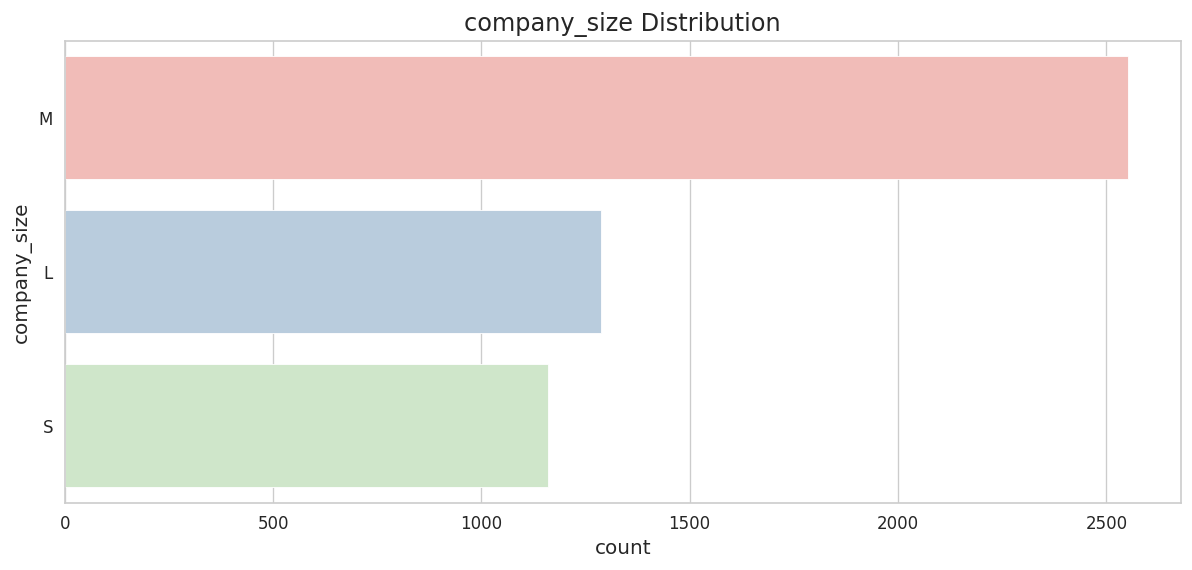

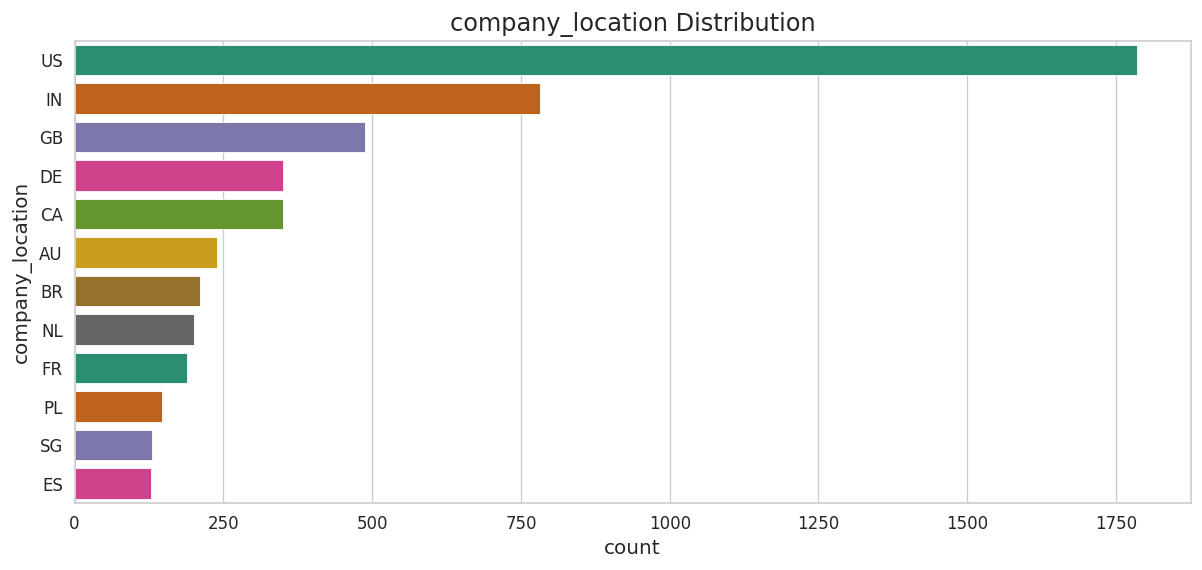

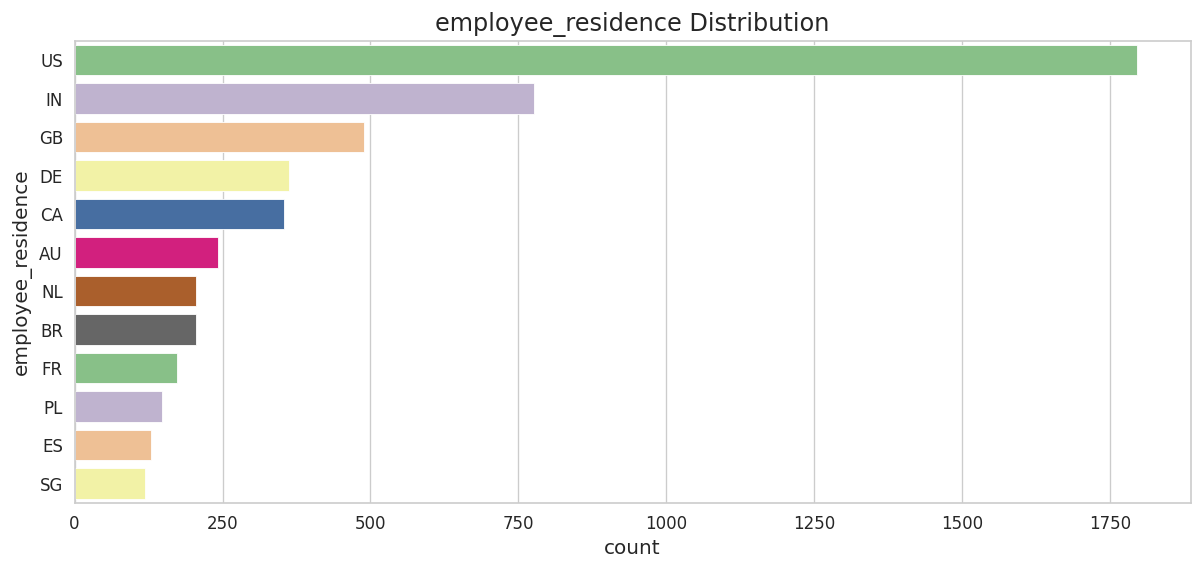

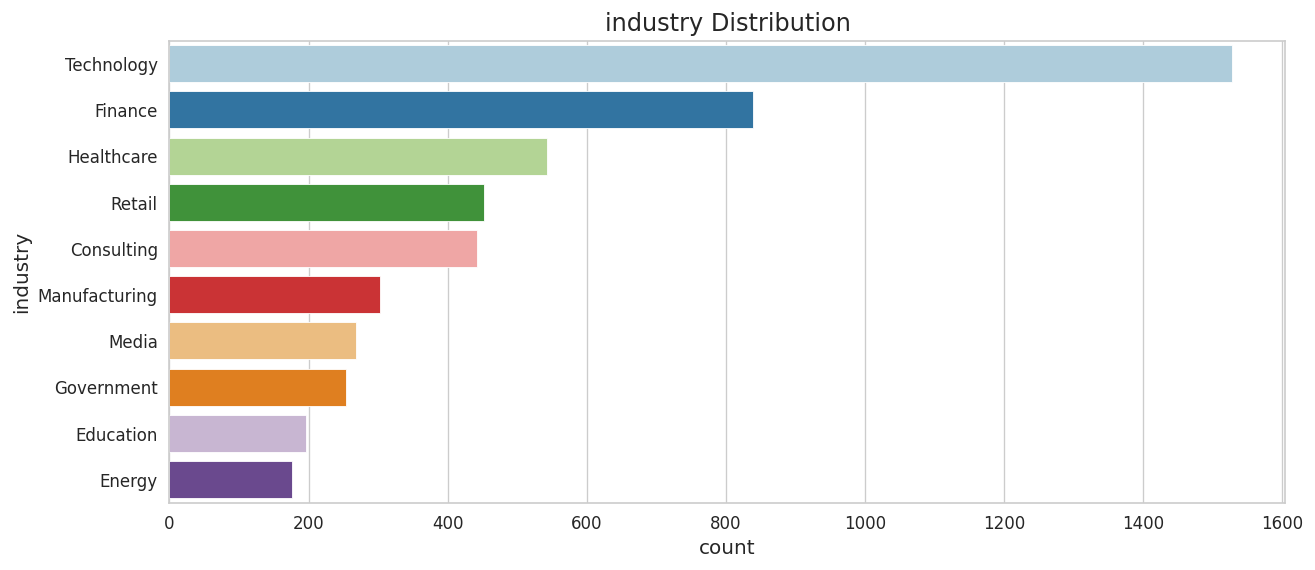

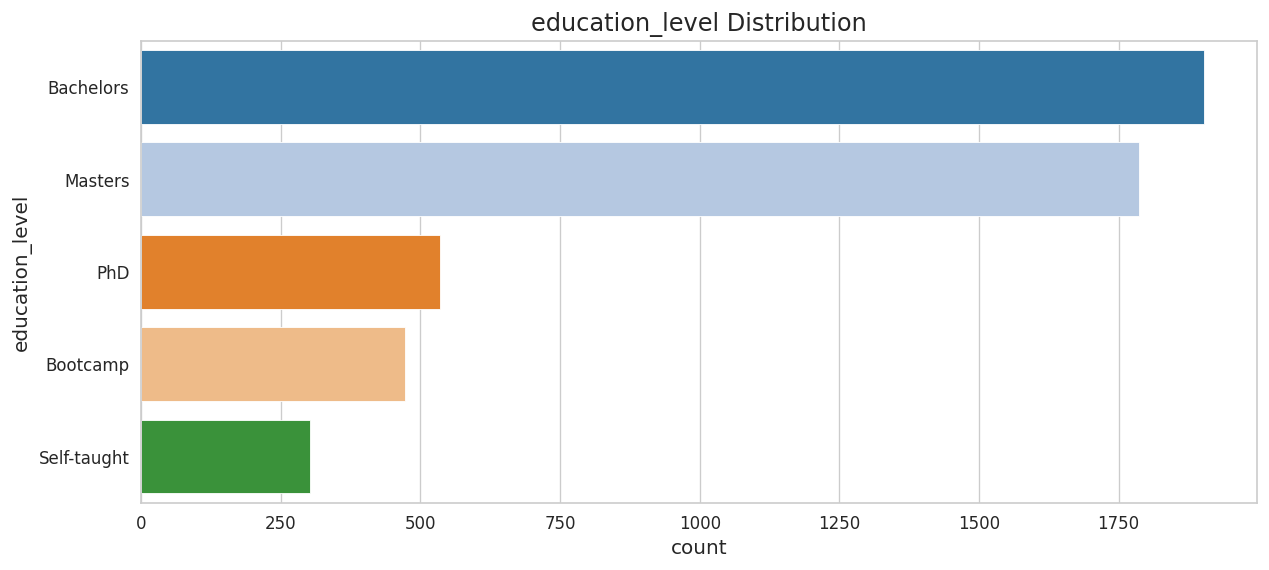

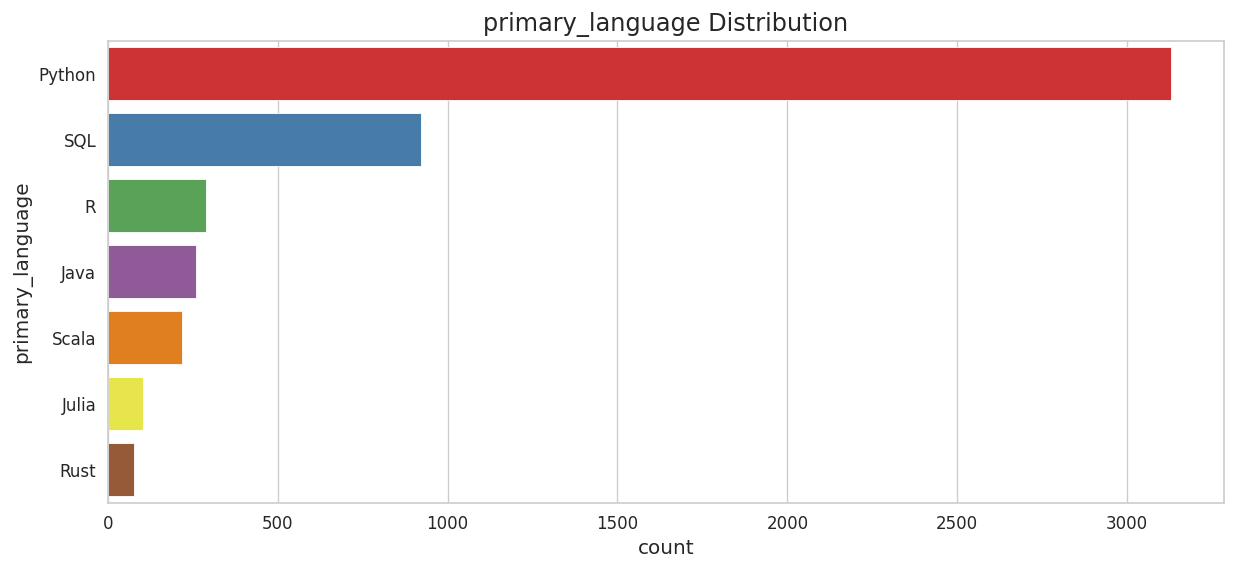

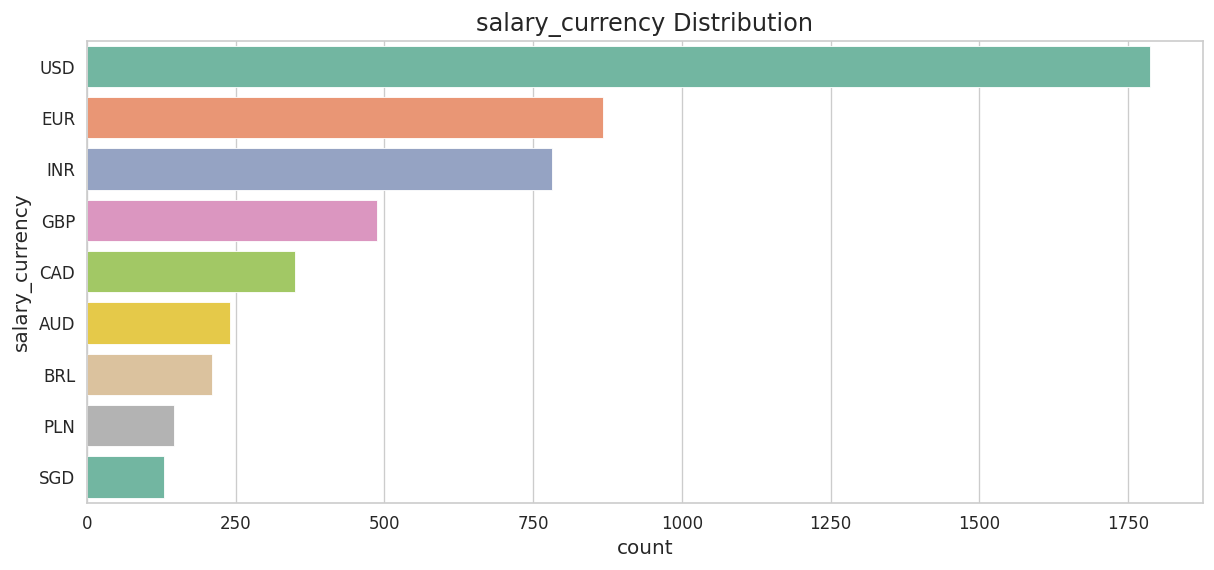

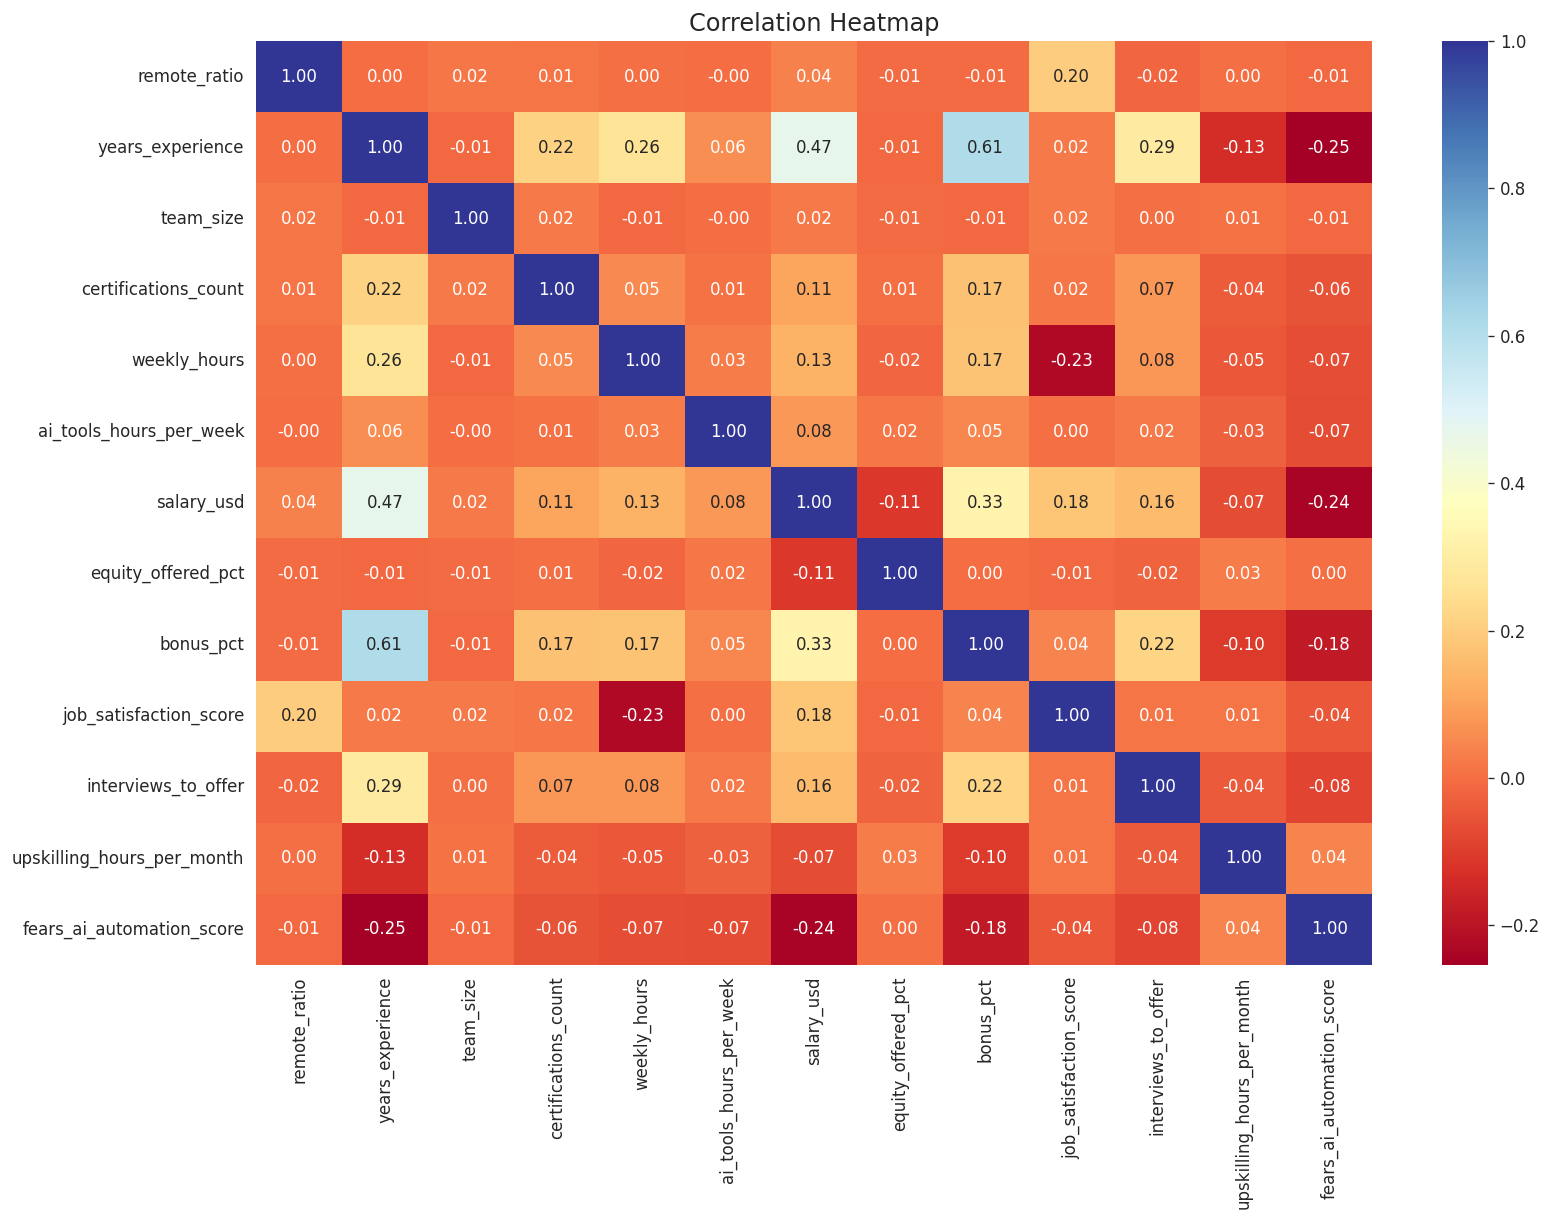

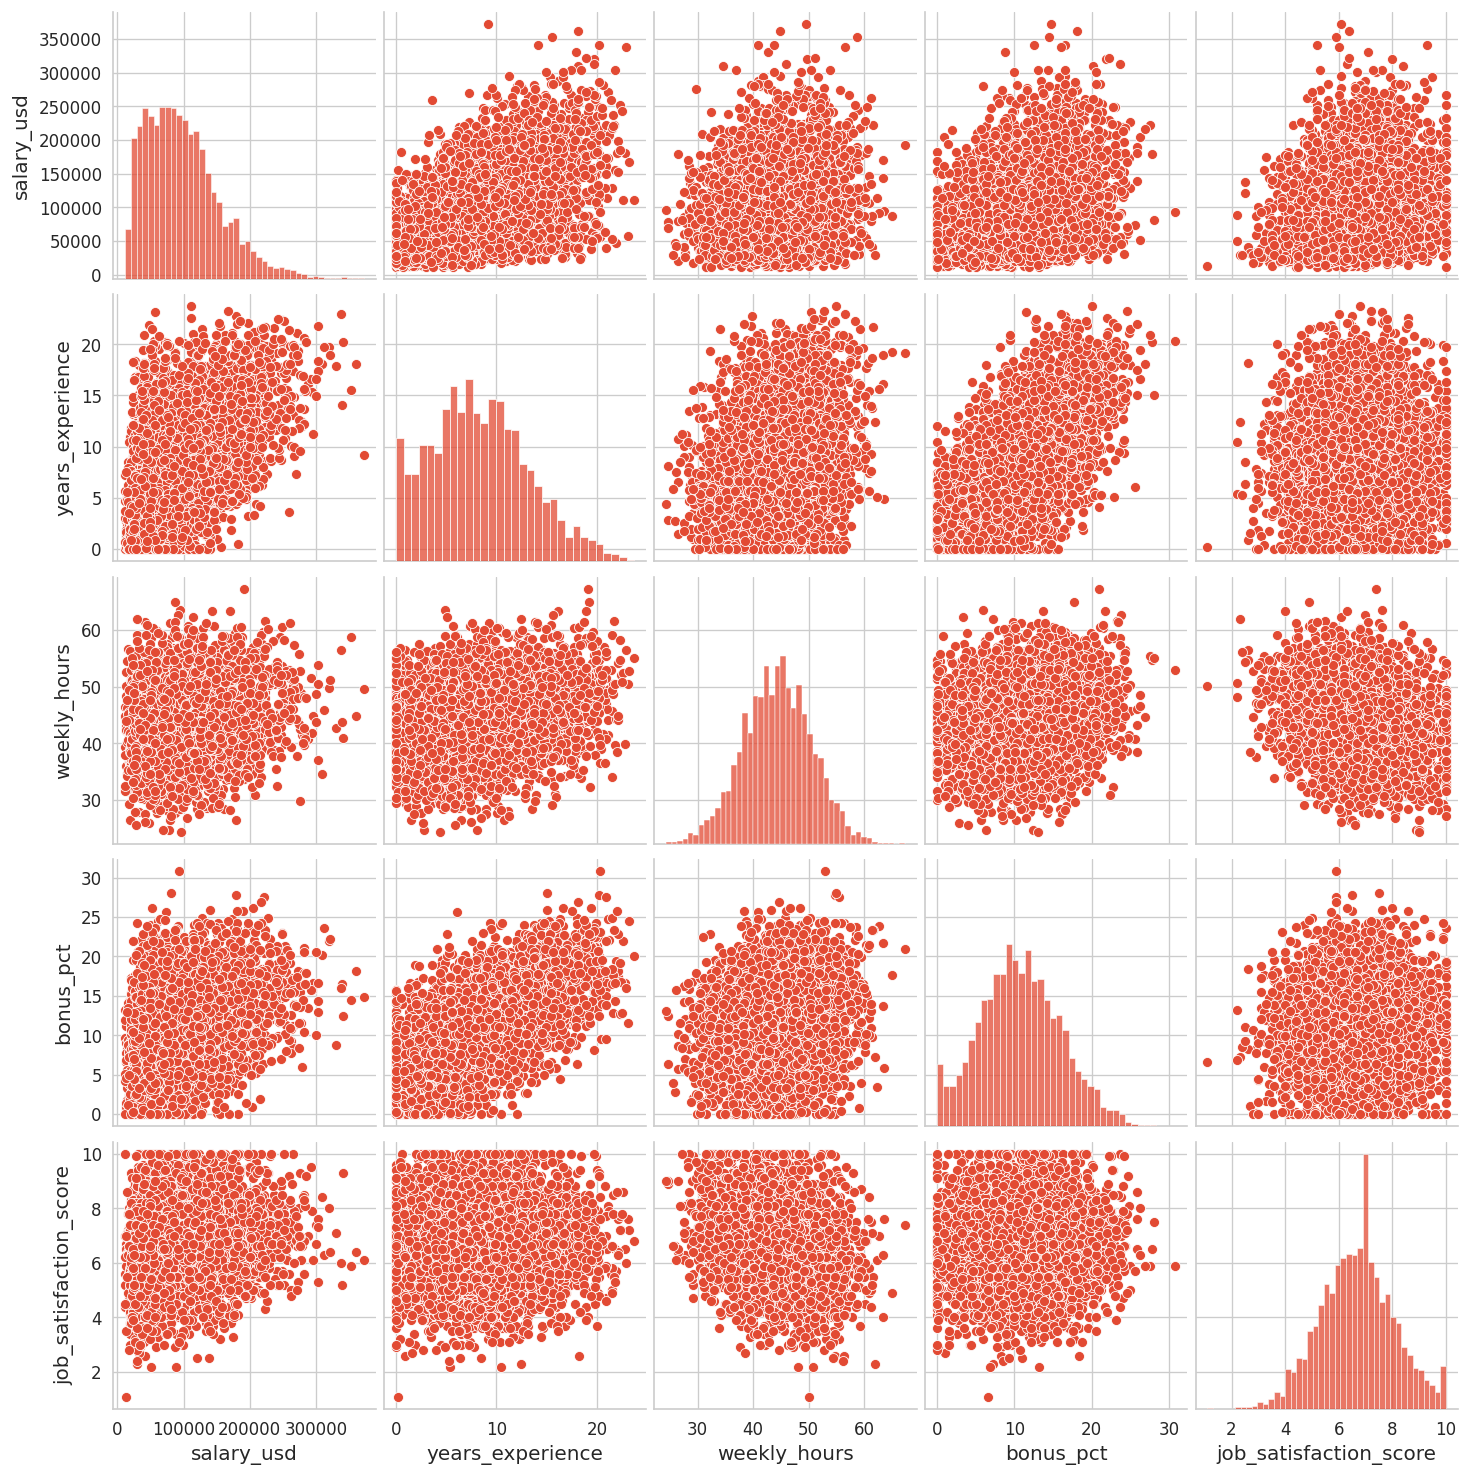

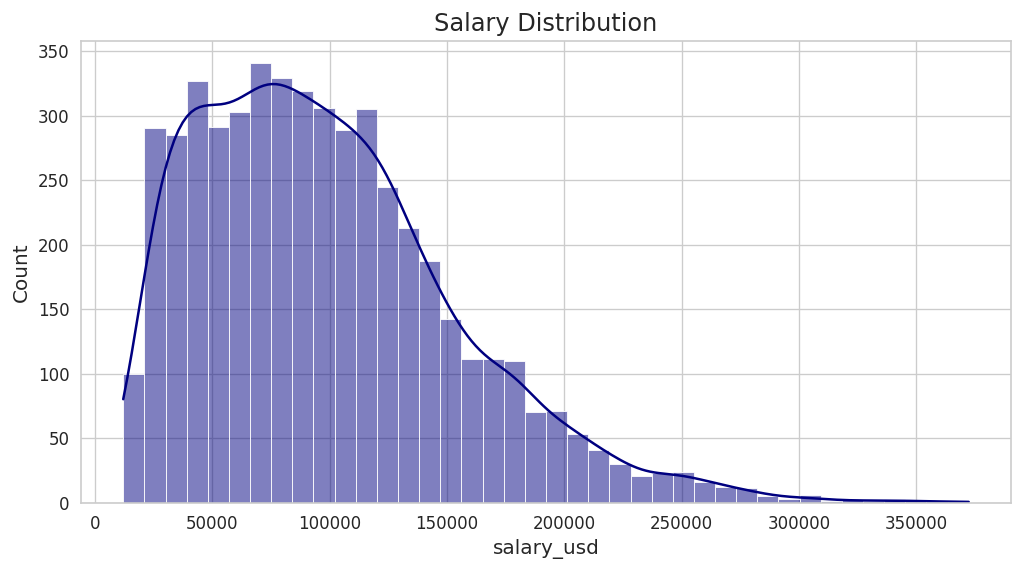

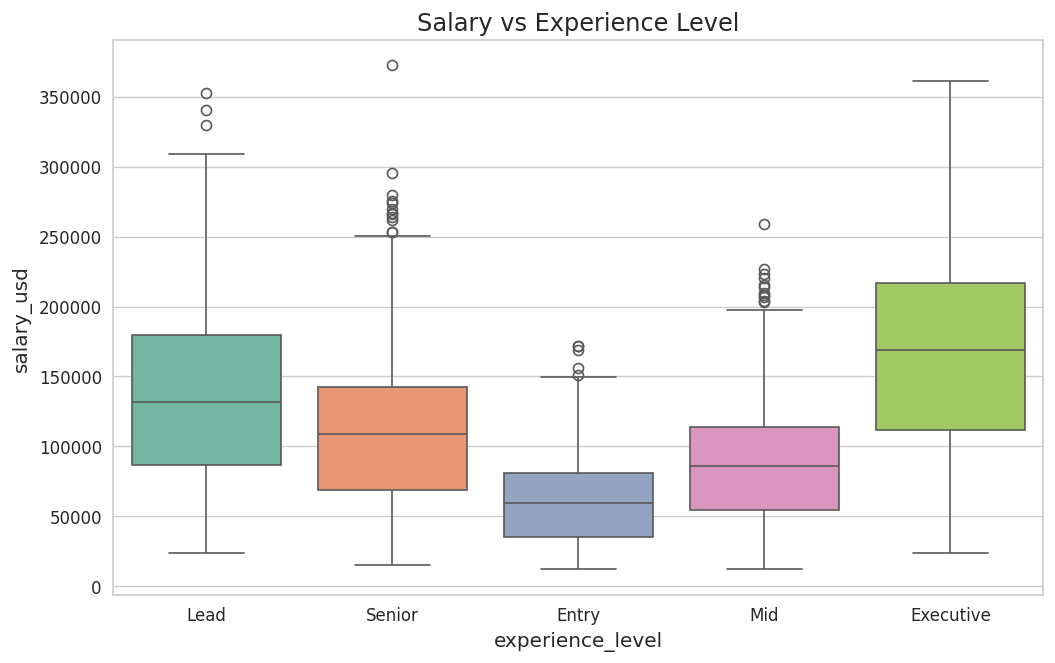

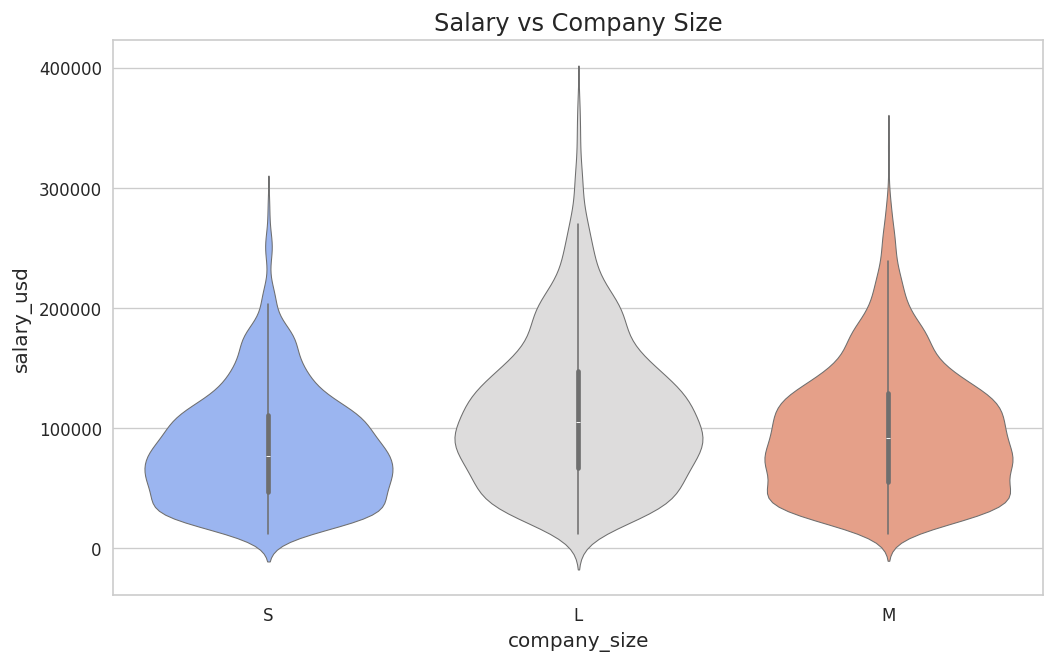

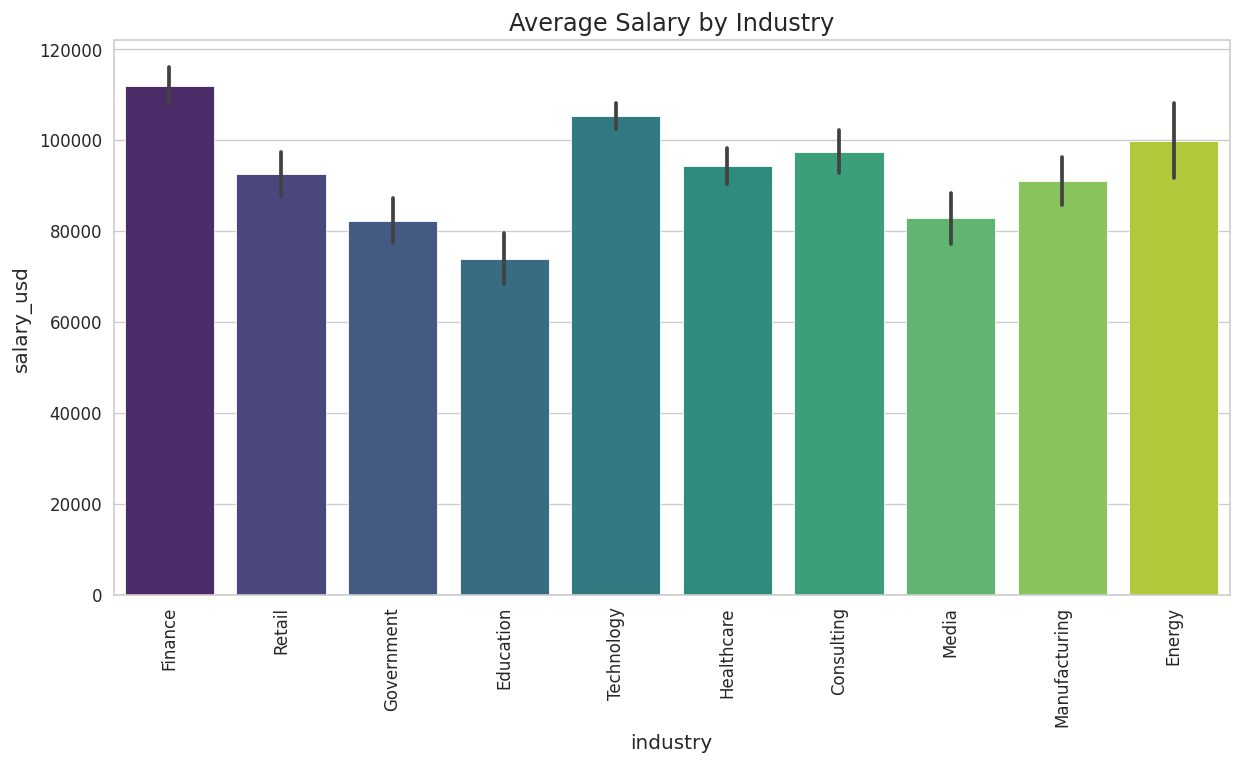

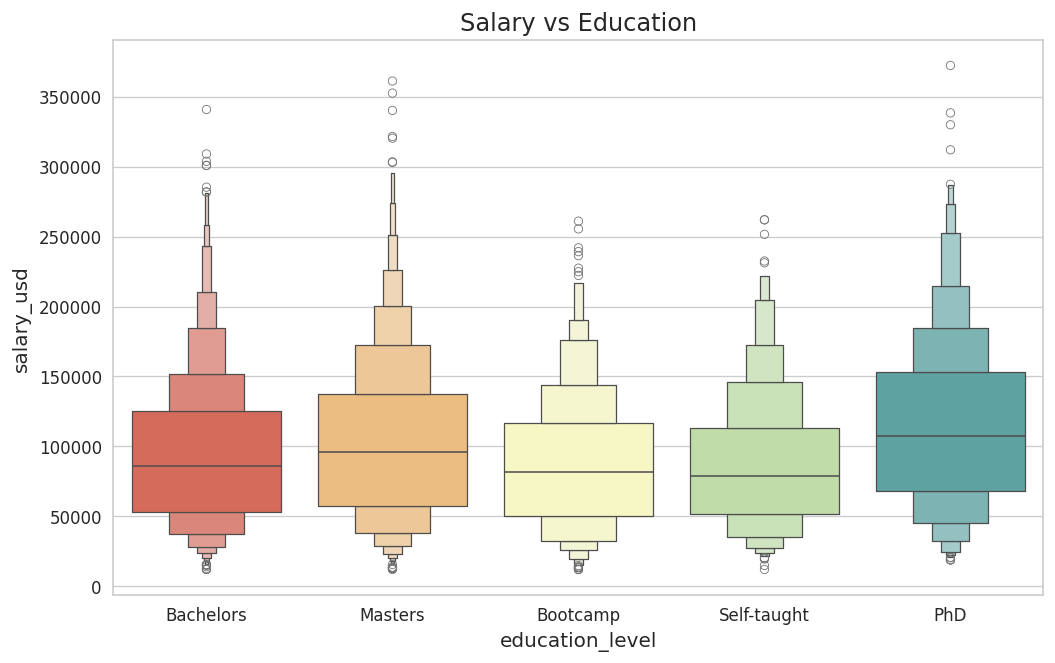

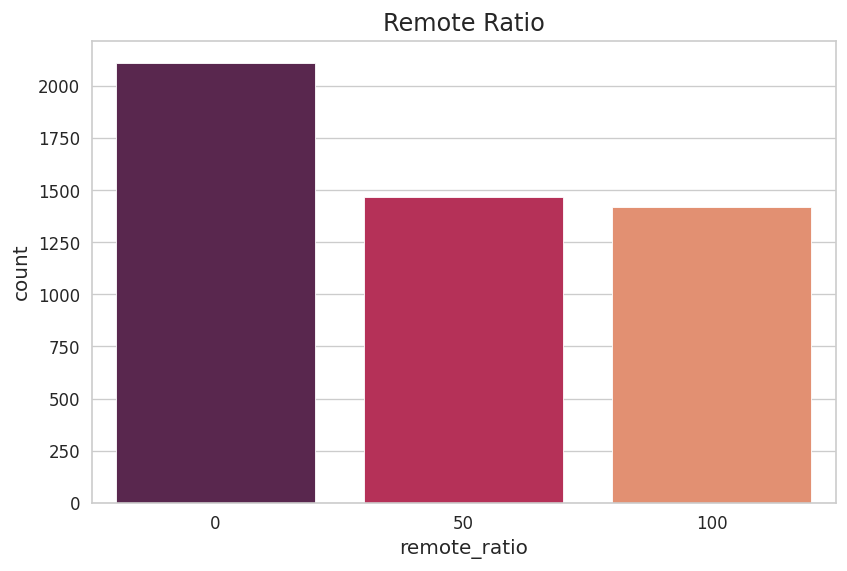

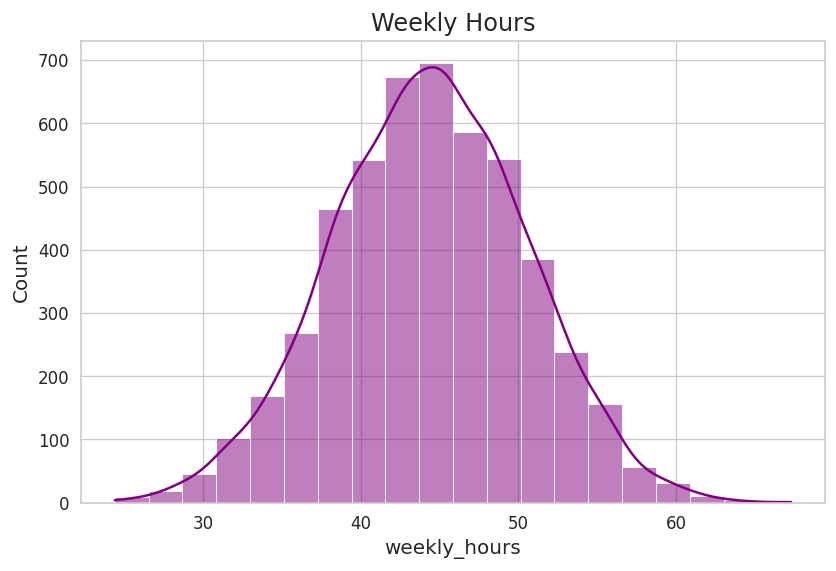

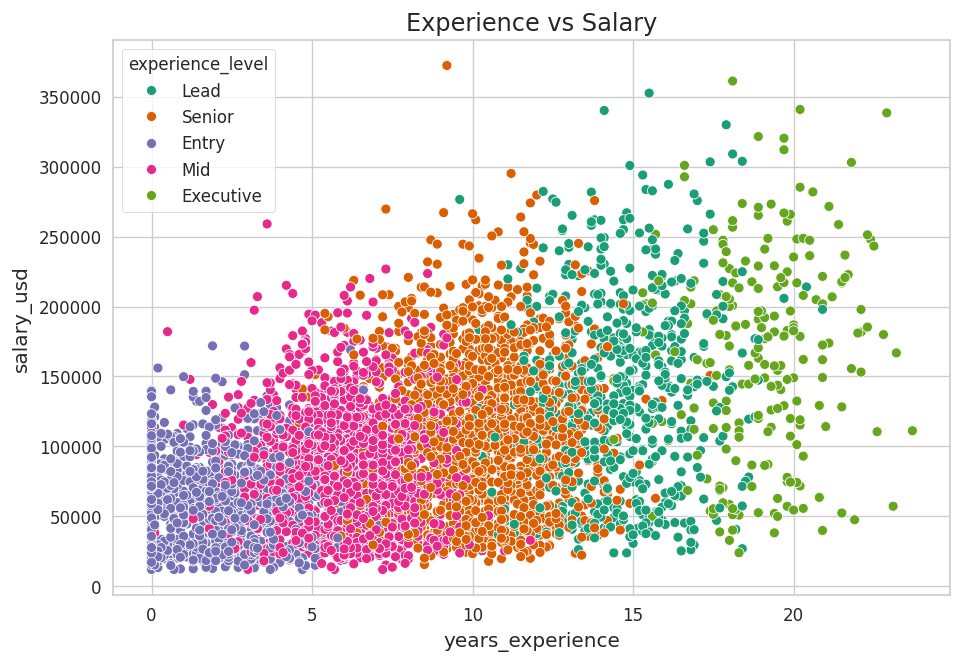

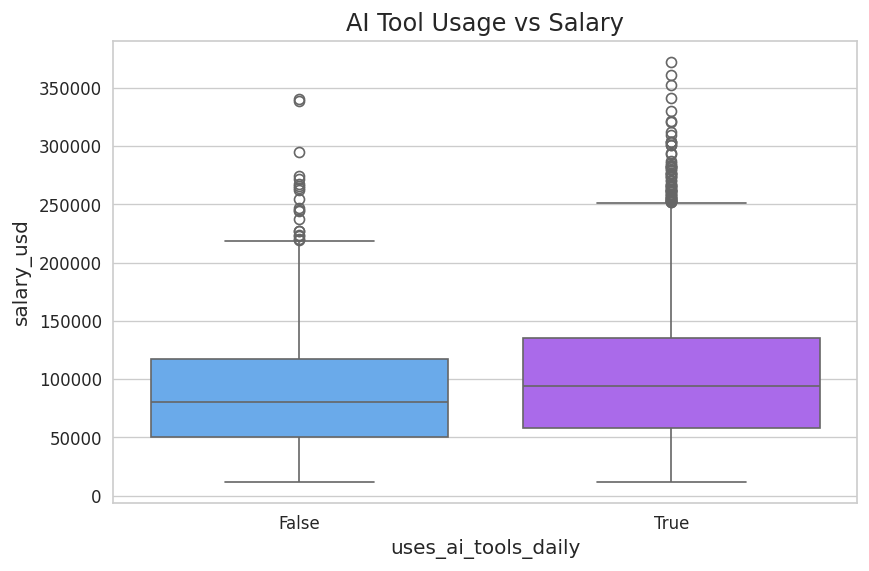

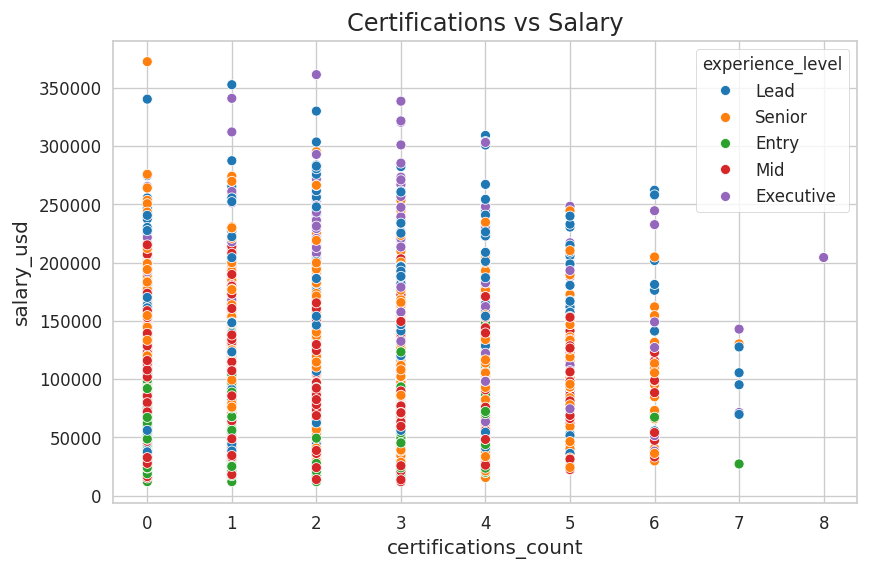

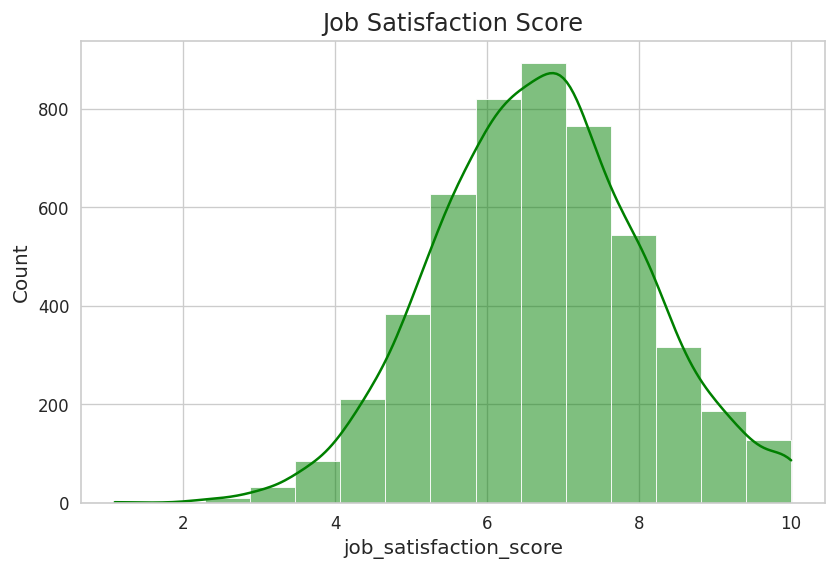

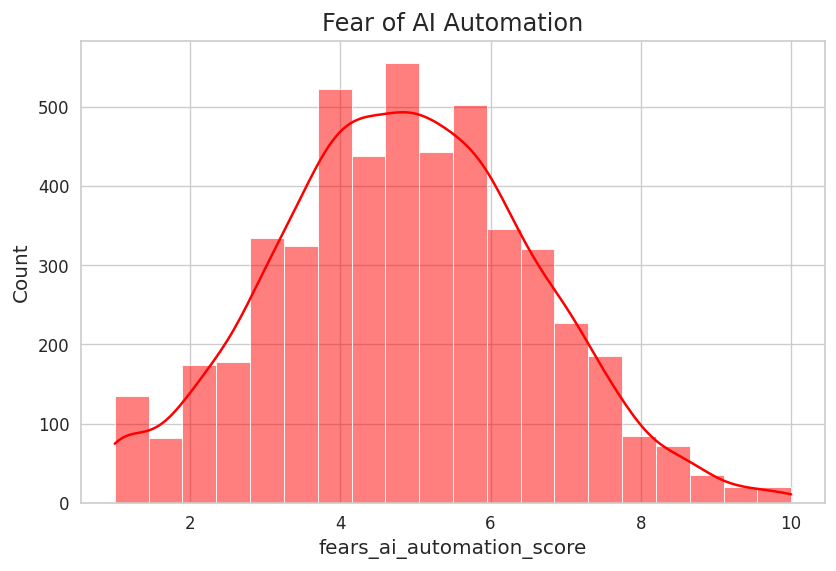

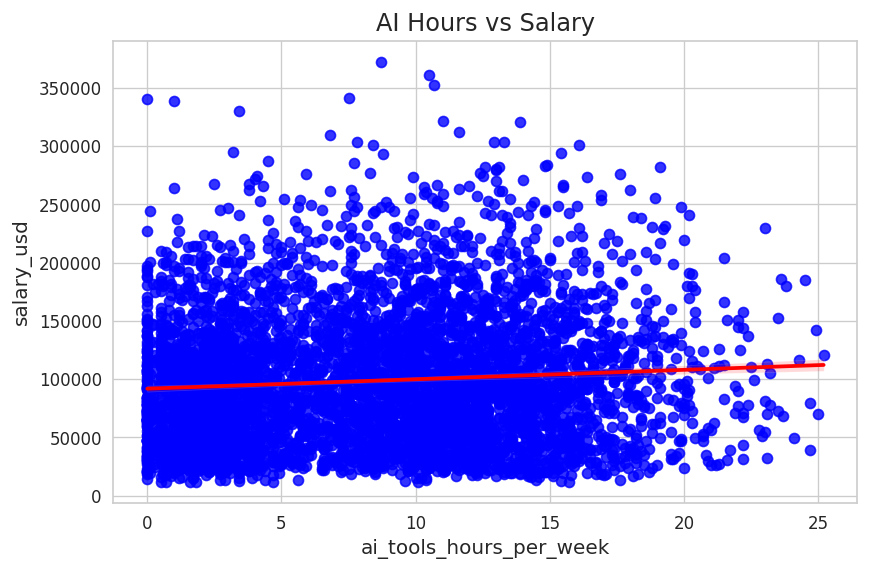

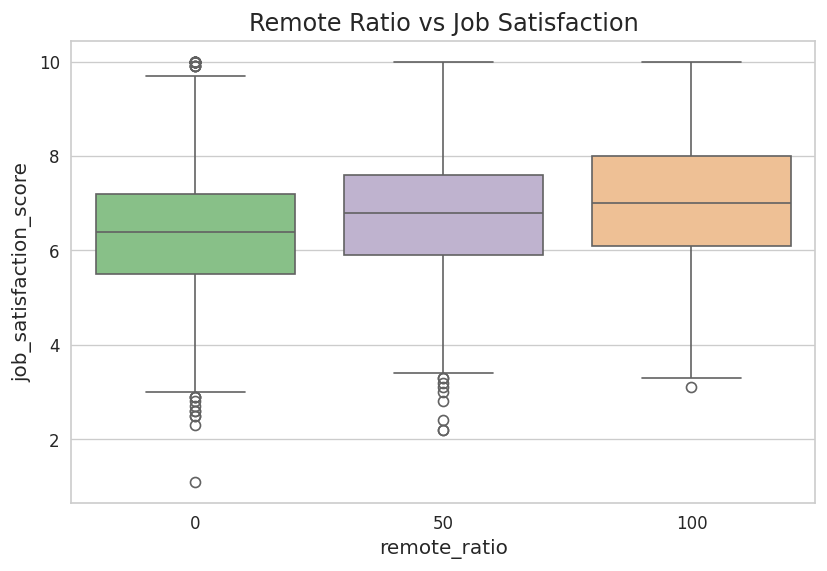

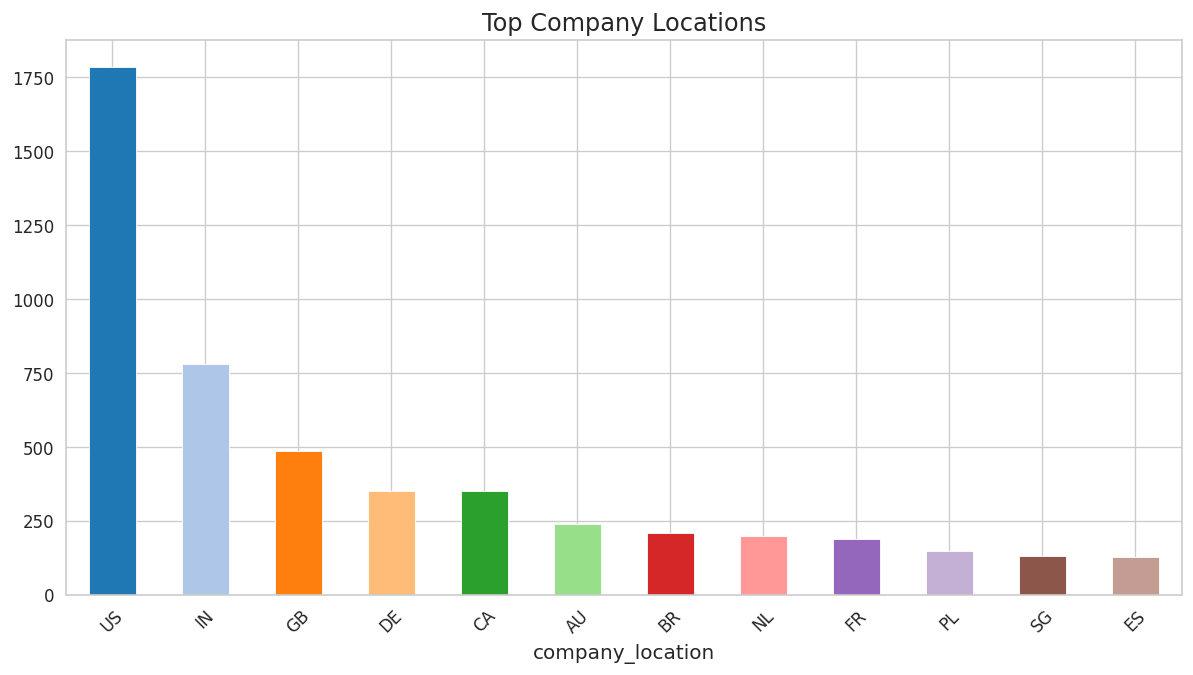

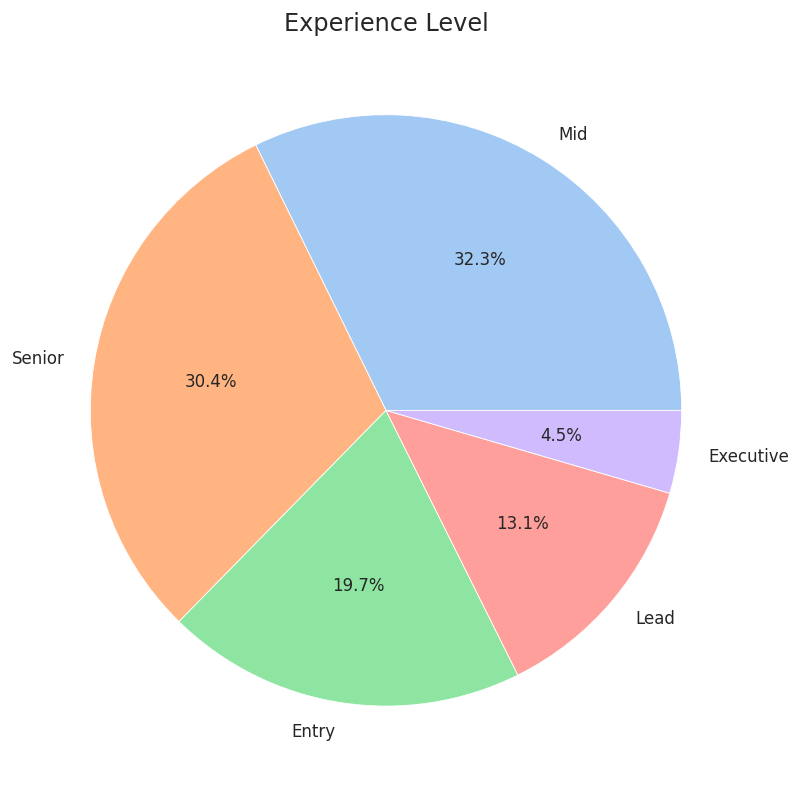

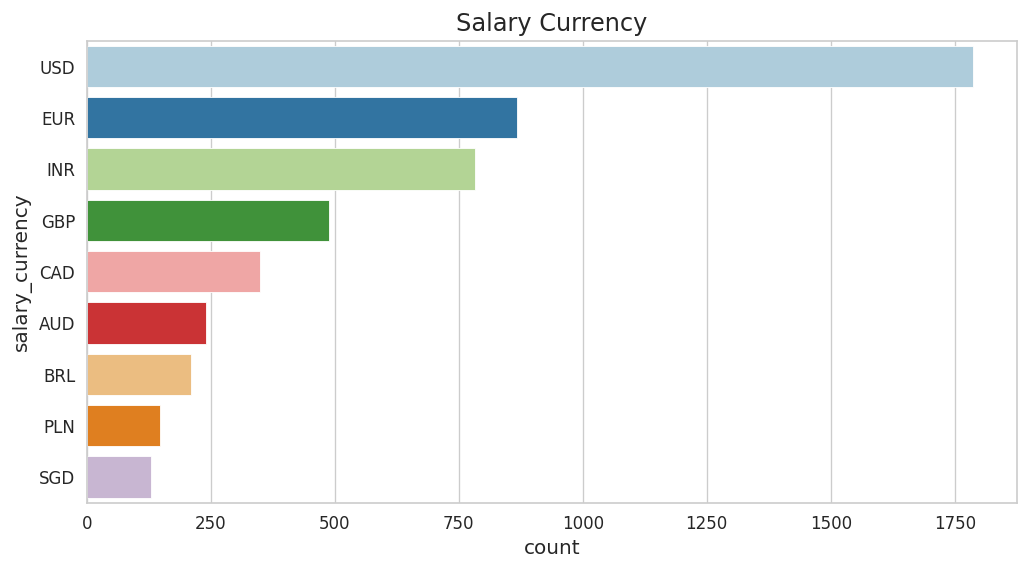

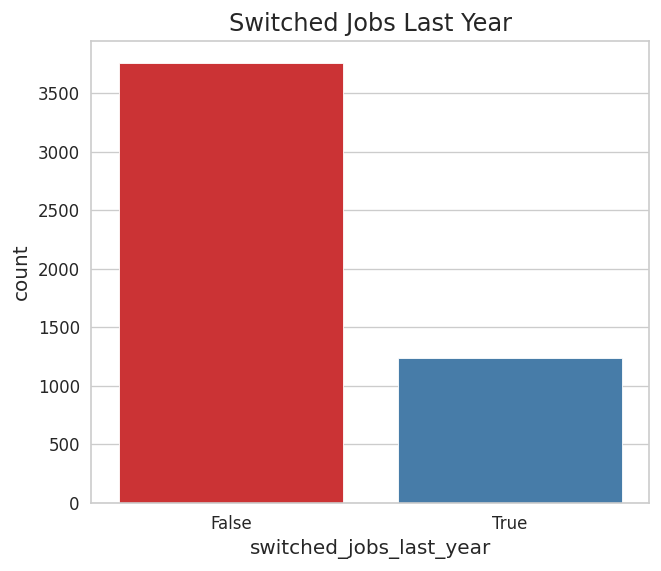

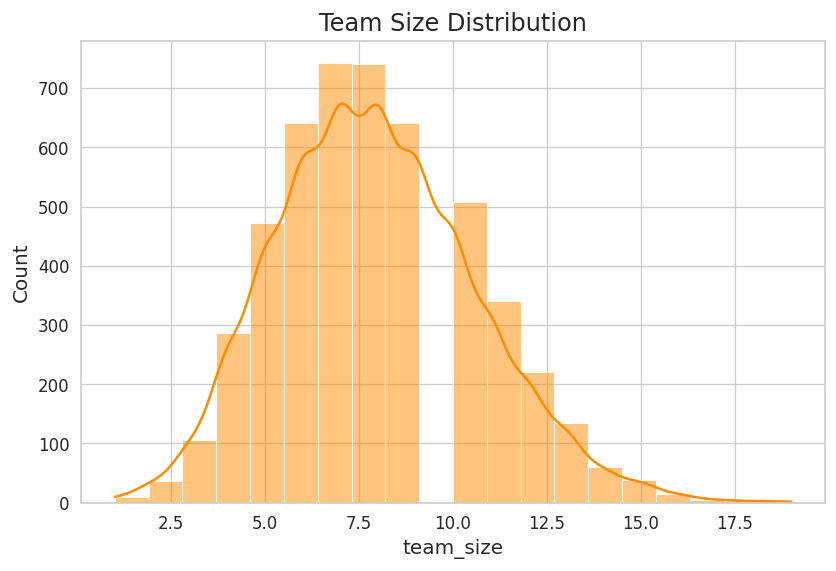

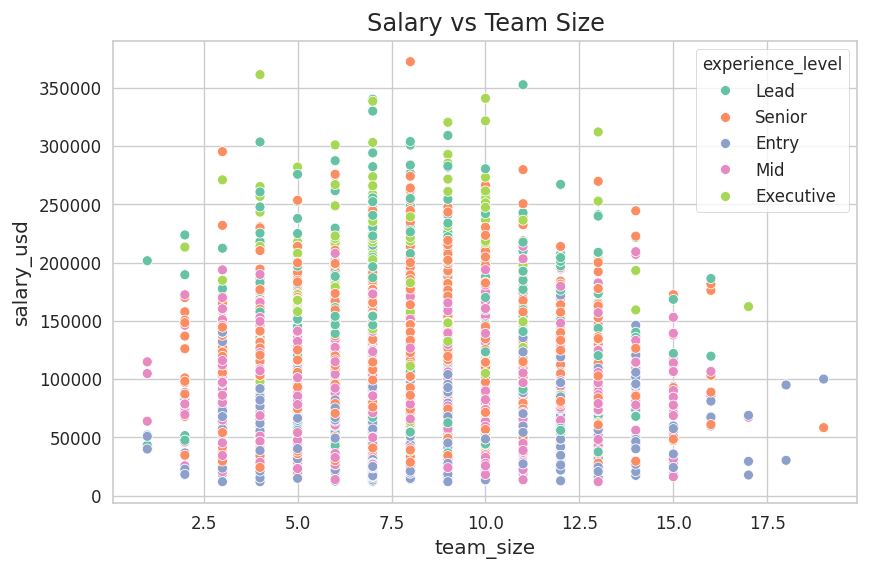

EDA COMPLETED SUCCESSFULLY


In [12]:
# ==========================
# COMPLETE EDA VISUALIZATION
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Style
# -----------------------------
plt.style.use("ggplot")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

# =============================
# Basic Information
# =============================

print("="*60)
print("DATASET SHAPE")
print(df.shape)

print("="*60)
print("DATASET INFO")
print(df.info())

print("="*60)
print("DESCRIBE")
print(df.describe(include="all"))

print("="*60)
print("NULL VALUES")
print(df.isnull().sum())

print("="*60)
print("DUPLICATES:", df.duplicated().sum())

# =============================
# Missing Values Heatmap
# =============================

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# =============================
# Missing Value Count
# =============================

missing = df.isnull().sum()

if missing.sum() > 0:
    plt.figure(figsize=(10,5))
    missing[missing>0].sort_values().plot(
        kind="barh",
        color="crimson"
    )
    plt.title("Missing Values Count")
    plt.show()

# =============================
# Numerical & Categorical Columns
# =============================

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

# =============================
# Histograms
# =============================

colors = [
    "red","blue","green","purple","orange",
    "brown","cyan","magenta","gold","teal"
]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color=colors[i%len(colors)]
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# =============================
# Boxplots
# =============================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col],
        color=colors[i%len(colors)]
    )

    plt.title(f"Boxplot of {col}")
    plt.show()

# =============================
# Countplots
# =============================

palettes = [
    "Set1","Set2","Set3","Pastel1",
    "Dark2","Accent","Paired","tab20"
]

for i,col in enumerate(cat_cols):

    plt.figure(figsize=(12,5))

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().head(15).index,
        palette=palettes[i%len(palettes)]
    )

    plt.title(f"{col} Distribution")
    plt.show()

# =============================
# Correlation Heatmap
# =============================

plt.figure(figsize=(15,10))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# =============================
# Pairplot
# =============================

selected = [col for col in [
    "salary_usd",
    "years_experience",
    "weekly_hours",
    "bonus_pct",
    "job_satisfaction_score"
] if col in df.columns]

if len(selected) > 1:
    sns.pairplot(df[selected])
    plt.show()

# =============================
# Salary Distribution
# =============================

if "salary_usd" in df.columns:

    plt.figure(figsize=(10,5))

    sns.histplot(
        df["salary_usd"],
        bins=40,
        kde=True,
        color="navy"
    )

    plt.title("Salary Distribution")
    plt.show()

# =============================
# Salary vs Experience
# =============================

if "experience_level" in df.columns:

    plt.figure(figsize=(10,6))

    sns.boxplot(
        x="experience_level",
        y="salary_usd",
        data=df,
        palette="Set2"
    )

    plt.title("Salary vs Experience Level")
    plt.show()

# =============================
# Salary vs Company Size
# =============================

if "company_size" in df.columns:

    plt.figure(figsize=(10,6))

    sns.violinplot(
        x="company_size",
        y="salary_usd",
        data=df,
        palette="coolwarm"
    )

    plt.title("Salary vs Company Size")
    plt.show()

# =============================
# Salary vs Industry
# =============================

if "industry" in df.columns:

    plt.figure(figsize=(12,6))

    sns.barplot(
        x="industry",
        y="salary_usd",
        data=df,
        estimator=np.mean,
        palette="viridis"
    )

    plt.xticks(rotation=90)
    plt.title("Average Salary by Industry")
    plt.show()

# =============================
# Salary vs Education
# =============================

if "education_level" in df.columns:

    plt.figure(figsize=(10,6))

    sns.boxenplot(
        x="education_level",
        y="salary_usd",
        data=df,
        palette="Spectral"
    )

    plt.title("Salary vs Education")
    plt.show()

# =============================
# Remote Ratio
# =============================

if "remote_ratio" in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        x="remote_ratio",
        data=df,
        palette="rocket"
    )

    plt.title("Remote Ratio")
    plt.show()

# =============================
# Weekly Hours
# =============================

if "weekly_hours" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["weekly_hours"],
        bins=20,
        kde=True,
        color="purple"
    )

    plt.title("Weekly Hours")
    plt.show()

# =============================
# Experience vs Salary
# =============================

if "years_experience" in df.columns:

    plt.figure(figsize=(9,6))

    sns.scatterplot(
        x="years_experience",
        y="salary_usd",
        hue="experience_level",
        palette="Dark2",
        data=df
    )

    plt.title("Experience vs Salary")
    plt.show()

# =============================
# AI Tools vs Salary
# =============================

if "uses_ai_tools_daily" in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x="uses_ai_tools_daily",
        y="salary_usd",
        data=df,
        palette="cool"
    )

    plt.title("AI Tool Usage vs Salary")
    plt.show()

# =============================
# Certifications vs Salary
# =============================

if "certifications_count" in df.columns:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        x="certifications_count",
        y="salary_usd",
        hue="experience_level",
        palette="tab10",
        data=df
    )

    plt.title("Certifications vs Salary")
    plt.show()

# =============================
# Job Satisfaction
# =============================

if "job_satisfaction_score" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["job_satisfaction_score"],
        bins=15,
        kde=True,
        color="green"
    )

    plt.title("Job Satisfaction Score")
    plt.show()

# =============================
# AI Fear Score
# =============================

if "fears_ai_automation_score" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["fears_ai_automation_score"],
        bins=20,
        kde=True,
        color="red"
    )

    plt.title("Fear of AI Automation")
    plt.show()

# =============================
# AI Hours vs Salary
# =============================

if "ai_tools_hours_per_week" in df.columns:

    plt.figure(figsize=(8,5))

    sns.regplot(
        x="ai_tools_hours_per_week",
        y="salary_usd",
        data=df,
        scatter_kws={"color":"blue"},
        line_kws={"color":"red"}
    )

    plt.title("AI Hours vs Salary")
    plt.show()

# =============================
# Remote vs Satisfaction
# =============================

if "remote_ratio" in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x="remote_ratio",
        y="job_satisfaction_score",
        data=df,
        palette="Accent"
    )

    plt.title("Remote Ratio vs Job Satisfaction")
    plt.show()

# =============================
# Top Company Locations
# =============================

if "company_location" in df.columns:

    plt.figure(figsize=(12,6))

    df["company_location"].value_counts().head(15).plot(
        kind="bar",
        color=sns.color_palette("tab20",15)
    )

    plt.title("Top Company Locations")
    plt.xticks(rotation=45)
    plt.show()

# =============================
# Experience Level Pie Chart
# =============================

if "experience_level" in df.columns:

    plt.figure(figsize=(8,8))

    df["experience_level"].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        colors=sns.color_palette("pastel")
    )

    plt.ylabel("")
    plt.title("Experience Level")
    plt.show()

# =============================
# Salary Currency
# =============================

if "salary_currency" in df.columns:

    plt.figure(figsize=(10,5))

    sns.countplot(
        y="salary_currency",
        data=df,
        order=df["salary_currency"].value_counts().head(10).index,
        palette="Paired"
    )

    plt.title("Salary Currency")
    plt.show()

# =============================
# Switched Job Last Year
# =============================

if "switched_jobs_last_year" in df.columns:

    plt.figure(figsize=(6,5))

    sns.countplot(
        x="switched_jobs_last_year",
        data=df,
        palette="Set1"
    )

    plt.title("Switched Jobs Last Year")
    plt.show()

# =============================
# Team Size Distribution
# =============================

if "team_size" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["team_size"],
        bins=20,
        kde=True,
        color="darkorange"
    )

    plt.title("Team Size Distribution")
    plt.show()

# =============================
# Salary vs Team Size
# =============================

if "team_size" in df.columns:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        x="team_size",
        y="salary_usd",
        hue="experience_level",
        palette="Set2",
        data=df
    )

    plt.title("Salary vs Team Size")
    plt.show()

print("="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)

## Features Engineering

Logistic Regression
Accuracy : 0.922
Precision: 0.9229
Recall   : 0.922
F1 Score : 0.9224
ROC AUC  : 0.9703

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.89      0.87       297
           1       0.95      0.94      0.94       703

    accuracy                           0.92      1000
   macro avg       0.90      0.91      0.91      1000
weighted avg       0.92      0.92      0.92      1000

Confusion Matrix

[[263  34]
 [ 44 659]]


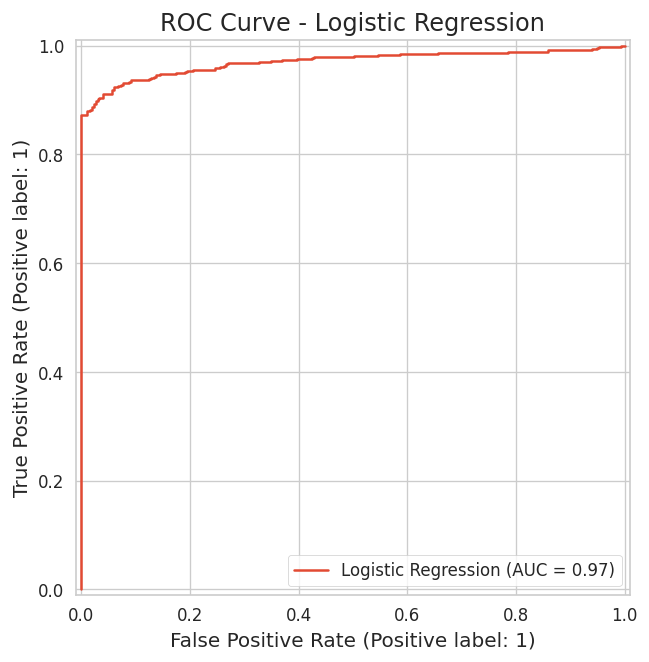

Decision Tree
Accuracy : 0.892
Precision: 0.8908
Recall   : 0.892
F1 Score : 0.8911
ROC AUC  : 0.8629

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       297
           1       0.91      0.93      0.92       703

    accuracy                           0.89      1000
   macro avg       0.88      0.86      0.87      1000
weighted avg       0.89      0.89      0.89      1000

Confusion Matrix

[[235  62]
 [ 46 657]]


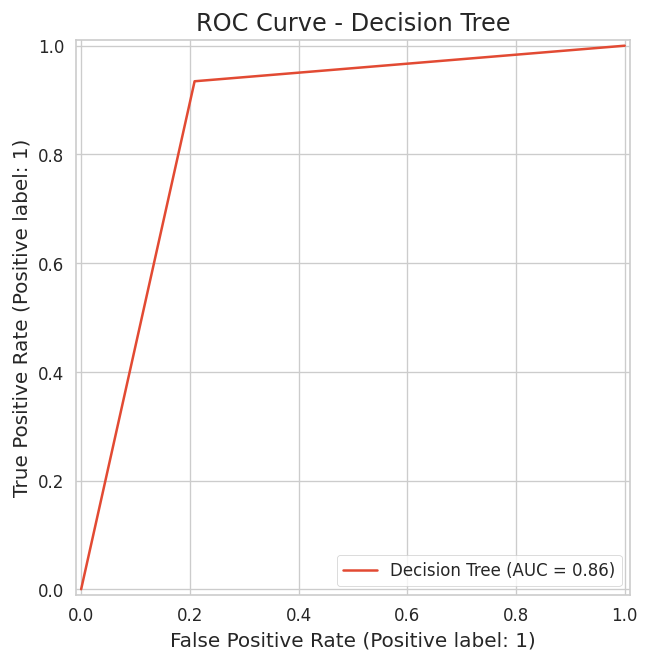

Random Forest
Accuracy : 0.925
Precision: 0.928
Recall   : 0.925
F1 Score : 0.9258
ROC AUC  : 0.9653

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       297
           1       0.96      0.93      0.95       703

    accuracy                           0.93      1000
   macro avg       0.90      0.92      0.91      1000
weighted avg       0.93      0.93      0.93      1000

Confusion Matrix

[[272  25]
 [ 50 653]]


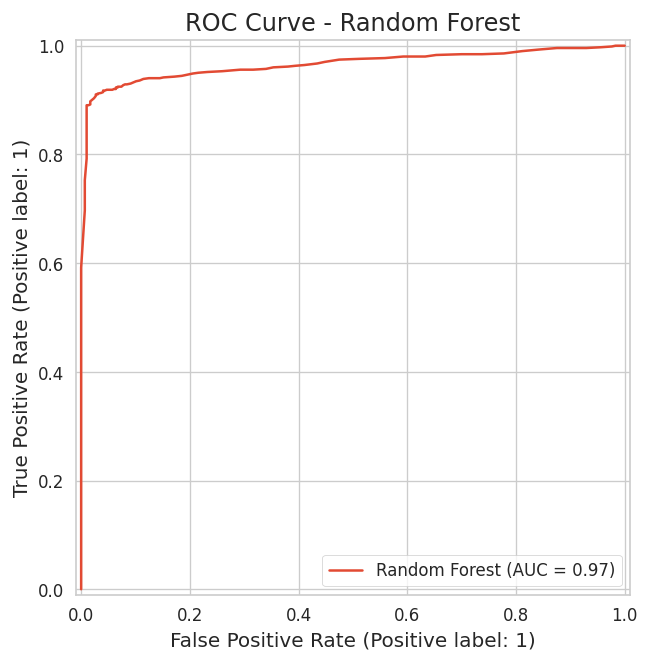

Gradient Boosting
Accuracy : 0.924
Precision: 0.9271
Recall   : 0.924
F1 Score : 0.9249
ROC AUC  : 0.9753

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       297
           1       0.96      0.93      0.94       703

    accuracy                           0.92      1000
   macro avg       0.90      0.92      0.91      1000
weighted avg       0.93      0.92      0.92      1000

Confusion Matrix

[[272  25]
 [ 51 652]]


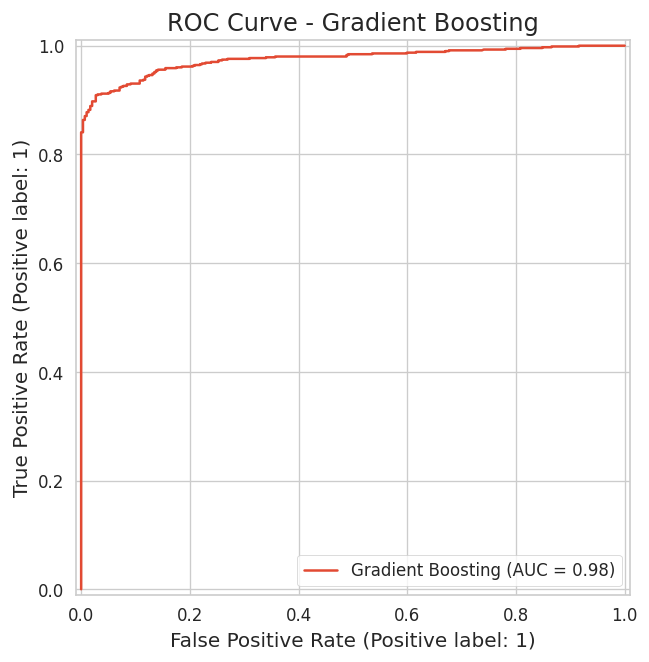

Extra Trees
Accuracy : 0.909
Precision: 0.9082
Recall   : 0.909
F1 Score : 0.9085
ROC AUC  : 0.9676

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.83      0.84       297
           1       0.93      0.94      0.94       703

    accuracy                           0.91      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.91      0.91      0.91      1000

Confusion Matrix

[[246  51]
 [ 40 663]]


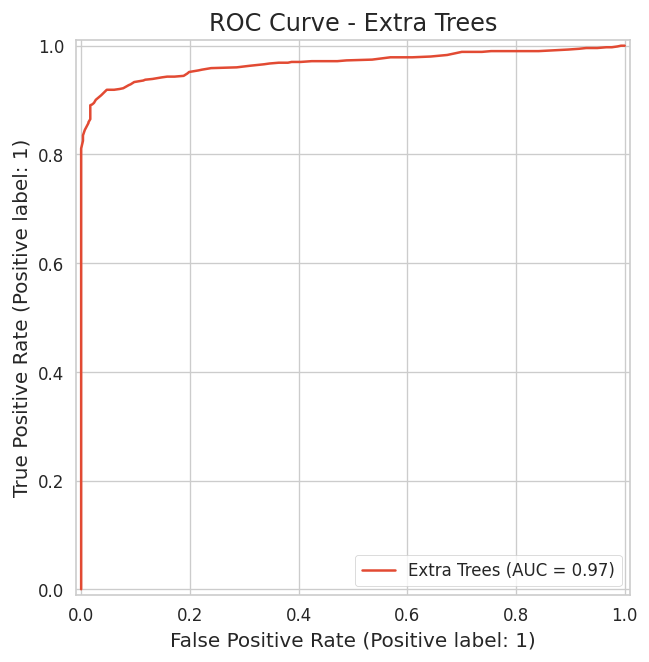

AdaBoost
Accuracy : 0.929
Precision: 0.9333
Recall   : 0.929
F1 Score : 0.93
ROC AUC  : 0.976

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.94      0.89       297
           1       0.97      0.93      0.95       703

    accuracy                           0.93      1000
   macro avg       0.91      0.93      0.92      1000
weighted avg       0.93      0.93      0.93      1000

Confusion Matrix

[[278  19]
 [ 52 651]]


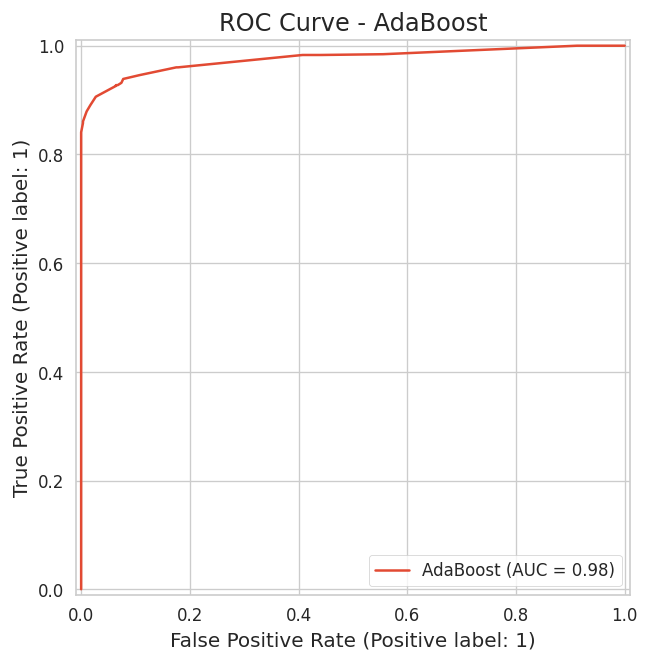

KNN
Accuracy : 0.628
Precision: 0.5774
Recall   : 0.628
F1 Score : 0.5948
ROC AUC  : 0.5053

Classification Report

              precision    recall  f1-score   support

           0       0.29      0.17      0.21       297
           1       0.70      0.82      0.76       703

    accuracy                           0.63      1000
   macro avg       0.49      0.50      0.48      1000
weighted avg       0.58      0.63      0.59      1000

Confusion Matrix

[[ 50 247]
 [125 578]]


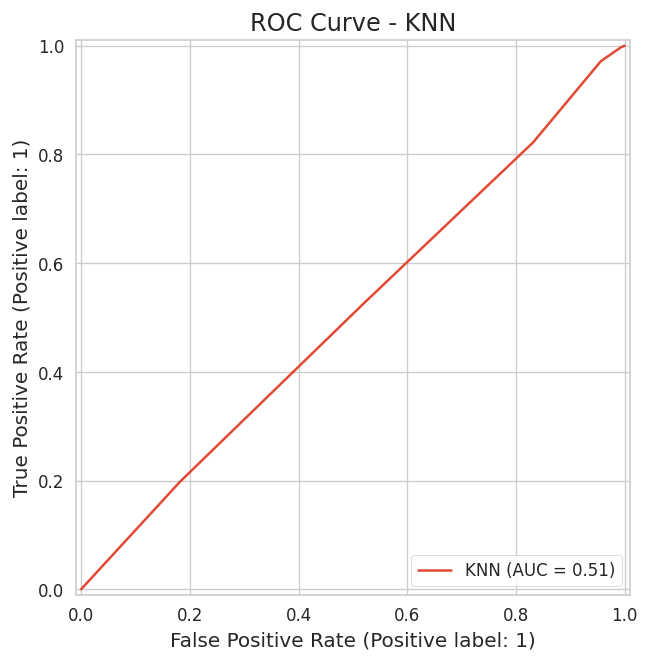

Gaussian NB
Accuracy : 0.922
Precision: 0.9274
Recall   : 0.922
F1 Score : 0.9233
ROC AUC  : 0.9691

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.93      0.88       297
           1       0.97      0.92      0.94       703

    accuracy                           0.92      1000
   macro avg       0.90      0.93      0.91      1000
weighted avg       0.93      0.92      0.92      1000

Confusion Matrix

[[277  20]
 [ 58 645]]


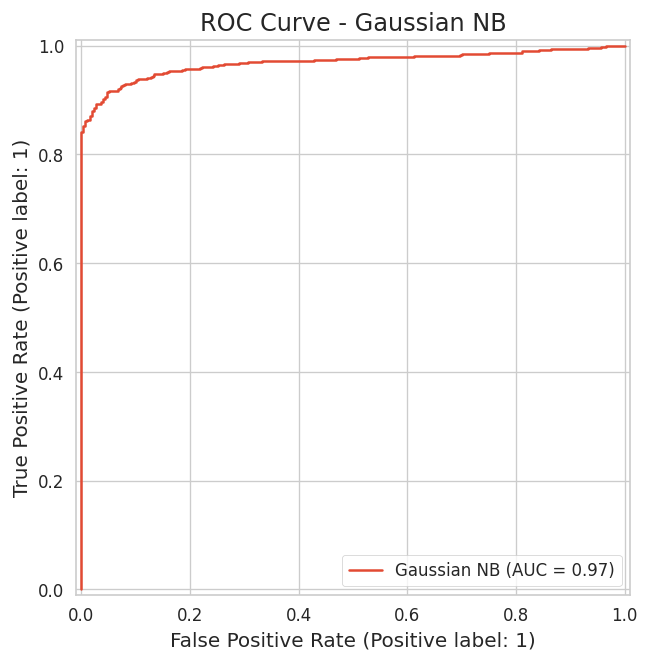

SVM
Accuracy : 0.703
Precision: 0.4942
Recall   : 0.703
F1 Score : 0.5804
ROC AUC  : 0.5176

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       297
           1       0.70      1.00      0.83       703

    accuracy                           0.70      1000
   macro avg       0.35      0.50      0.41      1000
weighted avg       0.49      0.70      0.58      1000

Confusion Matrix

[[  0 297]
 [  0 703]]


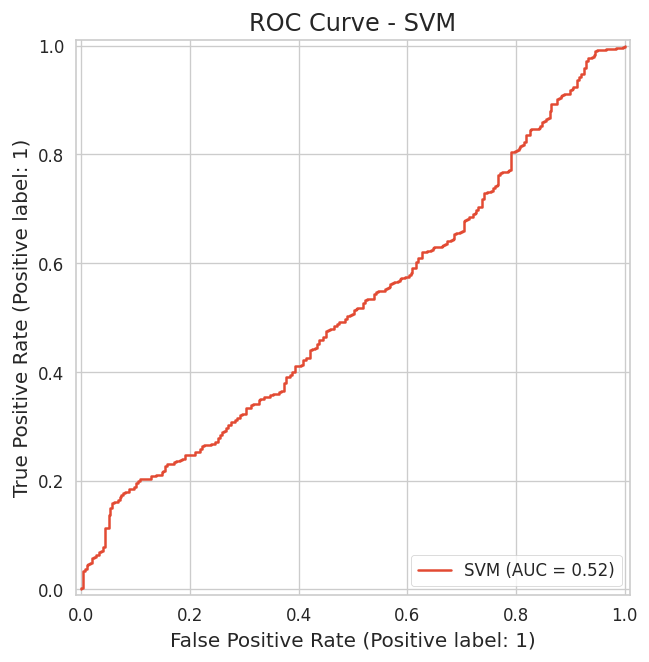


Final Comparison

                 Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
5             AdaBoost     0.929   0.933264   0.929  0.930015  0.975974
2        Random Forest     0.925   0.927960   0.925  0.925836  0.965274
3    Gradient Boosting     0.924   0.927145   0.924  0.924878  0.975322
0  Logistic Regression     0.922   0.922943   0.922  0.922366  0.970253
7          Gaussian NB     0.922   0.927436   0.922  0.923262  0.969093
4          Extra Trees     0.909   0.908247   0.909  0.908495  0.967647
1        Decision Tree     0.892   0.890760   0.892  0.891113  0.862906
8                  SVM     0.703   0.494209   0.703  0.580398  0.517580
6                  KNN     0.628   0.577383   0.628  0.594775  0.505321

Best Performing Model

Model        AdaBoost
Accuracy        0.929
Precision    0.933264
Recall          0.929
F1 Score     0.930015
ROC AUC      0.975974
Name: 5, dtype: object


In [13]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


# ==============================
# 3. Select Target
# ==============================

target = "uses_ai_tools_daily"

X = df.drop(columns=[target])
y = df[target]

# ==============================
# 4. Train Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==============================
# 5. Label Encoding (No Leakage)
# ==============================

categorical_cols = X_train.select_dtypes(include=['object']).columns

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    mapping = {
        label: idx
        for idx, label in enumerate(le.classes_)
    }

    X_test[col] = (
        X_test[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

    encoders[col] = le

# Encode Target

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train.astype(str))

target_mapping = {
    label: idx
    for idx, label in enumerate(target_encoder.classes_)
}

y_test = (
    y_test.astype(str)
    .map(target_mapping)
    .fillna(-1)
    .astype(int)
)

# ==============================
# 6. Models
# ==============================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Gaussian NB":
        GaussianNB(),

    "SVM":
        SVC(probability=True, random_state=42)

}

# ==============================
# 7. Train & Evaluate
# ==============================

results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probability
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    roc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc,4))

    print("\nClassification Report\n")

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    print("Confusion Matrix\n")

    print(confusion_matrix(
        y_test,
        y_pred
    ))

    # ROC Curve

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name
    )

    plt.title(f"ROC Curve - {name}")
    plt.grid(True)
    plt.show()

    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1,
        roc

    ])

# ==============================
# 8. Accuracy Comparison
# ==============================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nFinal Comparison\n")

print(results_df)

# ==============================
# 9. Best Model
# ==============================

best = results_df.iloc[0]

print("\nBest Performing Model\n")

print(best)

## Thanks..........Please Upvote